# Run Simulation

In [1]:
# import logging
# logging.basicConfig(level=logging.DEBUG)
# import sys
# sys.path.insert(0, "/Users/ddw/Desktop/Rescheduling")
# from run_simulation import run_simulation
# from utils.metrics import compute_metrics

# state, df, meta, _ = run_simulation(
#     n_freight            = 182,
#     trigger_strategy     = "periodic",
#     event_driven_freq    = 900,
#     mc_delay_per_train   = 40,
#     controller_freq      = 450,
#     periodic_freq        = 900,
#     threshold_confidence = 0.4,
#     objective_strategy   = "static",
#     upgrade_weight = 0,
#     weight_passenger     = 1,
#     weight_freight       = 1,
#     dynamic_threshold    = 180,
#     seed                 = 2,
#     save                 = False,
# )

# if meta["deadlock_detected"]:
#     print("DEADLOCK gedetecteerd — run incomplete, metrics niet beschikbaar.")
# else:
#     metrics = compute_metrics(df)
#     print(f"TED_passenger : {metrics['TED_passenger']:,.0f}s")
#     print(f"TED_freight   : {metrics['TED_freight']:,.0f}s")
#     print(f"TED_combined  : {metrics['TED_combined']:,.0f}s")
#     print(f"delay_ratio   : {metrics['delay_ratio']:.3f}" if metrics['delay_ratio'] else "delay_ratio   : N/A")
#     print(f"n_rescheduled : {meta['controller_summary']['n_rescheduled']}")

In [2]:
import logging
logging.basicConfig(level=logging.DEBUG)

import sys
sys.path.insert(0, "/Users/ddw/Desktop/Rescheduling")

from run_simulation import run_simulation
from utils.metrics import compute_metrics
from data.loader import load_all


# ------------------------------------------------------------
# LOAD DOMAIN OBJECTS
# ------------------------------------------------------------

trains, segments, timetable = load_all(n_freight=182)


# ------------------------------------------------------------
# RUN SIMULATION
# ------------------------------------------------------------

state, df, meta, _ , simulator= run_simulation(
    n_freight            = 182,
    trigger_strategy     = "periodic",
    event_driven_freq    = 900,
    mc_delay_per_train   = 180,
    controller_freq      = 1800,
    periodic_freq        = 50000,
    threshold_confidence = 0.6,
    objective_strategy   = "static",
    upgrade_weight       = 0,
    weight_passenger     = 1,
    weight_freight       = 1,
    dynamic_threshold    = 180,
    seed                 = 1,
    save                 = False,
)


# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

if meta["deadlock_detected"]:
    print("DEADLOCK gedetecteerd — run incomplete, metrics niet beschikbaar.")
else:
    metrics = compute_metrics(df)

    print(f"TED_passenger : {metrics['TED_passenger']:,.0f}s")
    print(f"TED_freight   : {metrics['TED_freight']:,.0f}s")
    print(f"TED_combined  : {metrics['TED_combined']:,.0f}s")
    print(
        f"delay_ratio   : {metrics['delay_ratio']:.3f}"
        if metrics['delay_ratio']
        else "delay_ratio   : N/A"
    )
    print(f"n_rescheduled : {meta['controller_summary']['n_rescheduled']}")


# ------------------------------------------------------------
# DEBUG FUNCTION
# ------------------------------------------------------------

import pandas as pd


def compare_train(train_id, state, timetable, trains):

    rows = []

    train = trains[train_id]

    for seg in train.path:

        sched_entry = timetable.scheduled_entry(train_id, seg)
        sched_exit  = timetable.scheduled_exit(train_id, seg)

        try:
            actual_entry = state.actual_entry(train_id, seg)
        except KeyError:
            actual_entry = None

        try:
            actual_exit = state.actual_exit(train_id, seg)
        except KeyError:
            actual_exit = None

        entry_delay = (
            actual_entry - sched_entry
            if actual_entry is not None else None
        )

        exit_delay = (
            actual_exit - sched_exit
            if actual_exit is not None else None
        )

        rows.append({
            "segment": seg,
            "scheduled_entry": sched_entry,
            "actual_entry": actual_entry,
            "entry_delay": entry_delay,
            "scheduled_exit": sched_exit,
            "actual_exit": actual_exit,
            "exit_delay": exit_delay,
        })

    df_debug = pd.DataFrame(rows)

    numeric_cols = [
        "scheduled_entry",
        "actual_entry",
        "entry_delay",
        "scheduled_exit",
        "actual_exit",
        "exit_delay",
    ]

    df_debug[numeric_cols] = df_debug[numeric_cols].round(1)

    return df_debug


# ------------------------------------------------------------
# EXAMPLE
# ------------------------------------------------------------

display(compare_train(900000, state, timetable, trains))

INFO:data.timetable:Gold geladen (passenger): 1028 treinen, 10072 segmenten
INFO:data.timetable:Gold geladen (freight): 182 treinen, 734 segmenten
INFO:data.combine_timetable:Gecombineerd: 1210 treinen (1028 passenger, 182 freight), 10806 segmenten
INFO:data.loader:Treinen geladen: 1210
INFO:data.loader:Segmenten geladen: 132
INFO:data.loader:Timetable geladen: 10806 (train_no, segment_id) combinaties
INFO:data.timetable:Gold geladen (passenger): 1028 treinen, 10072 segmenten
INFO:data.timetable:Gold geladen (freight): 182 treinen, 734 segmenten
INFO:data.combine_timetable:Gecombineerd: 1210 treinen (1028 passenger, 182 freight), 10806 segmenten


Loading data...


INFO:data.loader:Treinen geladen: 1210
INFO:data.loader:Segmenten geladen: 132
INFO:data.loader:Timetable geladen: 10806 (train_no, segment_id) combinaties


Building controller (trigger=periodic, objective=static)...
Running simulation...
Set parameter Username


INFO:gurobipy:Set parameter Username


...

INFO:gurobipy:Set parameter LicenseID to value 2811974


Academic license - for non-commercial use only - expires 2027-04-22


INFO:gurobipy:Academic license - for non-commercial use only - expires 2027-04-22


[t=50037] T=240 S=125 conf=4808 vars=11045 constr=16800 bin=4808
[t=50037s] RESCHEDULED — status=optimal, objective=2069.22, solver_runtime=0.30s
Processing results...
Done. 10806 rows, 1210 trains.
Controller: {'n_rescheduled': 1, 'n_fcfs_fallback': 0, 'n_skipped': 10900, 'n_evaluated': 0, 'total_steps': 10901, 'total_solver_runtime_s': 0.29679107666015625, 'max_consecutive_failures': 0}
TED_passenger : 16,811s
TED_freight   : 5,999s
TED_combined  : 22,810s
delay_ratio   : 2.016
n_rescheduled : 1


,segment,scheduled_entry,actual_entry,entry_delay,scheduled_exit,actual_exit,exit_delay
0,28(1):BRUSSEL-ZUID-BRUSSEL-WEST,30756.0,30756.0,0.0,31146.0,31146.0,0.0
1,BRUSSEL-WEST,31146.0,31146.0,0.0,31147.0,31147.0,0.0
2,28(1):BRUSSEL-WEST-SIMONIS,31147.0,31147.0,0.0,31238.0,31238.0,0.0
3,SIMONIS,31238.0,31238.0,0.0,31239.0,31239.0,0.0
4,28(1):SIMONIS-THURN EN TAXIS,31239.0,31239.0,0.0,31330.0,31330.0,0.0
5,THURN EN TAXIS,31330.0,31330.0,0.0,31331.0,31331.0,0.0
6,28:THURN EN TAXIS-SCHAARBEEK,31331.0,31331.0,0.0,31744.0,31744.0,0.0
7,SCHAARBEEK,31744.0,31744.0,0.0,31745.0,31745.0,0.0
8,36N:SCHAARBEEK-BRUSSEL-NOORD,31745.0,31745.0,0.0,31979.0,31979.0,0.0


In [3]:
# 1. Heeft de trein überhaupt iets in _actual?
print("actual dict:", state._actual.get(900000))
print("current_segment:", state._current_segment.get(900000))
print("is_finished:", state.is_finished(900000))
print("remaining_path:", state.remaining_path(900000))

# 2. Stond er een TrainEntered voor 900000 in de queue, en is de sim er voorbij?
print("eindtijd simulatie:", state.current_time)
print("eerste scheduled_entry 900000:", timetable.scheduled_entry(900000, trains[900000].path[0]))

# 3. Hoeveel treinen hebben WEL gedraaid? Staat 900000 echt in de geladen set?
print("900000 in trains:", 900000 in trains)
ran = [t for t in trains if state._actual.get(t)]
print(f"treinen met geregistreerde activiteit: {len(ran)} / {len(trains)}")
not_started = [t for t in trains if not state._actual.get(t)]
print(f"treinen die nooit startten: {len(not_started)}")
print("voorbeelden niet-gestart:", not_started[:10])

actual dict: {'28(1):BRUSSEL-ZUID-BRUSSEL-WEST': (30756.0, 31146.0), 'BRUSSEL-WEST': (31146.0, 31147.0), '28(1):BRUSSEL-WEST-SIMONIS': (31147.0, 31238.0), 'SIMONIS': (31238.0, 31239.0), '28(1):SIMONIS-THURN EN TAXIS': (31239.0, 31330.0), 'THURN EN TAXIS': (31330.0, 31331.0), '28:THURN EN TAXIS-SCHAARBEEK': (31331.0, 31744.0), 'SCHAARBEEK': (31744.0, 31745.0), '36N:SCHAARBEEK-BRUSSEL-NOORD': (31745.0, 31979.0)}
current_segment: None
is_finished: True
remaining_path: []
eindtijd simulatie: 87183.0
eerste scheduled_entry 900000: 30756.0
900000 in trains: True
treinen met geregistreerde activiteit: 1210 / 1210
treinen die nooit startten: 0
voorbeelden niet-gestart: []


In [4]:
# A. Delen veel treinen hetzelfde eerste segment? (gedeelde-bezetting hypothese)
from collections import Counter
first_segs = Counter(trains[t].first_segment for t in trains)
print("Top 10 meest-gedeelde eerste segmenten:")
for seg, cnt in first_segs.most_common(10):
    print(f"  {cnt:4d} treinen starten op  {seg}")

# B. Van de 150 die WEL draaiden — wat is hun eerste segment, en hoe laat startten ze?
ran = [t for t in trains if state._actual.get(t)]
print(f"\n{len(ran)} treinen draaiden. Hun start-tijden:")
start_times = sorted(
    state.actual_entry(t, trains[t].first_segment) for t in ran
)
print(f"  vroegste start: {start_times[0]:.0f}s")
print(f"  laatste start:  {start_times[-1]:.0f}s")

# C. Bestaat het eerste segment van 900000 wel in de segments-dict / dispatcher?
t0 = trains[900000].first_segment
print(f"\n900000 first_segment: {t0!r}")
print(f"  in segments dict: {t0 in segments}")

# D. Hoeveel events zaten er nog in de queue toen de sim 'klaar' was?
#    (al leeg, maar: hoeveel stale-skips? voeg desnoods een counter toe)

Top 10 meest-gedeelde eerste segmenten:
   192 treinen starten op  36N:SCHAARBEEK-BRUSSEL-NOORD
   158 treinen starten op  0-1:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK
   107 treinen starten op  0-3:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK
    99 treinen starten op  25:SCHAARBEEK-BRUSSEL-NOORD
    92 treinen starten op  36:SCHAARBEEK-BRUSSEL-NOORD
    82 treinen starten op  50C:ANDERLECHT-BRUSSEL-ZUID
    79 treinen starten op  25:BRUSSEL-NOORD-SCHAARBEEK
    70 treinen starten op  161:BRUSSEL-SCHUMAN-BRUSSEL-NOORD
    65 treinen starten op  0-5:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK
    65 treinen starten op  124:VORST-OOST-BRUSSEL-ZUID

1210 treinen draaiden. Hun start-tijden:
  vroegste start: 0s
  laatste start:  86223s

900000 first_segment: '28(1):BRUSSEL-ZUID-BRUSSEL-WEST'
  in segments dict: True


In [5]:
# 1. Geven de draaiende treinen hun segmenten netjes vrij? Check eindbezetting:
occupied_now = {s: t for s, t in simulator._dispatcher._occupied.items() if t is not None}
print(f"Segmenten nog bezet aan einde sim: {len(occupied_now)}")
for s, t in list(occupied_now.items())[:20]:
    print(f"  {s!r} bezet door trein {t}")

# 2. Van de 1048 niet-gestarte treinen: delen ze hun eerste segment met EEN
#    van de bezet-gebleven segmenten? (= achter een vastzittende trein)
not_started = [t for t in trains if not state._actual.get(t)]
stuck_segs = set(occupied_now.keys())
blocked_behind = [t for t in not_started if trains[t].first_segment in stuck_segs]
print(f"\nNiet-gestart EN eerste segment is nog bezet: {len(blocked_behind)} / {len(not_started)}")

# 3. KRITIEK: hoeveel treinen zijn 'finished'? En hoeveel hangen halverwege?
finished = [t for t in trains if state.is_finished(t)]
active_end = state.active_train_ids()
print(f"\nfinished: {len(finished)}")
print(f"actief aan einde (gestart, niet af): {len(active_end)}")
print(f"nooit gestart: {len(not_started)}")
print(f"som: {len(finished) + len(active_end) + len(not_started)} (moet {len(trains)} zijn)")

# 4. Van de 160 die draaiden: hoeveel zijn ECHT finished vs hangen vast?
ran = [t for t in trains if state._actual.get(t)]
ran_finished = [t for t in ran if state.is_finished(t)]
print(f"\nvan {len(ran)} gedraaide treinen: {len(ran_finished)} finished, {len(ran)-len(ran_finished)} hangen halverwege")

Segmenten nog bezet aan einde sim: 0

Niet-gestart EN eerste segment is nog bezet: 0 / 0

finished: 1210
actief aan einde (gestart, niet af): 0
nooit gestart: 0
som: 1210 (moet 1210 zijn)

van 1210 gedraaide treinen: 1210 finished, 0 hangen halverwege


In [6]:
import pandas as pd

rows = []

for train_id, train in trains.items():

    max_delay = 0
    worst_segment = None
    planned_exit_worst = None
    actual_exit_worst = None

    for seg in train.path:

        try:
            actual_exit = state.actual_exit(train_id, seg)
        except KeyError:
            continue

        planned_exit = timetable.scheduled_exit(train_id, seg)

        delay = actual_exit - planned_exit

        if delay > max_delay:
            max_delay = delay
            worst_segment = seg
            planned_exit_worst = planned_exit
            actual_exit_worst = actual_exit

    rows.append({
        "train_id": train_id,
        "train_type": train.train_type.value,
        "max_delay_sec": round(max_delay, 1),
        "max_delay_min": round(max_delay / 60, 2),
        "worst_segment": worst_segment,
        "planned_exit": planned_exit_worst,
        "actual_exit": actual_exit_worst,
    })

df_worst_actual = (
    pd.DataFrame(rows)
    .sort_values("max_delay_sec", ascending=False)
    .reset_index(drop=True)
)

display(df_worst_actual.head(20))

,train_id,train_type,max_delay_sec,max_delay_min,worst_segment,planned_exit,actual_exit
0,4516,P,3601.0,60.02,0-5:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK,62403.0,66004.0
1,2314,P,3600.0,60.00,BRUSSEL-ZUID -- IC 23-2: OOSTENDE -> BRUSSELS ...,62463.0,66063.0
2,900177,F,537.0,8.95,SCHAARBEEK,14129.0,14666.0
3,900111,F,524.0,8.73,28:THURN EN TAXIS-SCHAARBEEK,14142.0,14666.0
4,3859,P,409.0,6.82,BRUSSEL-WEST -- platform 2,35463.0,35872.0
5,3862,P,409.0,6.82,BRUSSEL-WEST -- platform 2,46263.0,46672.0
6,3865,P,409.0,6.82,BRUSSEL-WEST -- platform 2,57063.0,57472.0
7,3858,P,409.0,6.82,BRUSSEL-WEST -- platform 2,31863.0,32272.0
8,3855,P,409.0,6.82,BRUSSEL-WEST -- platform 2,21063.0,21472.0
9,900133,F,363.0,6.05,36N:SCHAARBEEK-BRUSSEL-NOORD,21411.0,21774.0


DEBUG:matplotlib:matplotlib data path: /Users/ddw/Desktop/Rescheduling/venv/lib/python3.13/site-packages/matplotlib/mpl-data
DEBUG:matplotlib:CONFIGDIR=/Users/ddw/.matplotlib
DEBUG:matplotlib:interactive is False
DEBUG:matplotlib:platform is darwin
DEBUG:matplotlib:CACHEDIR=/Users/ddw/.matplotlib
DEBUG:matplotlib.font_manager:Using fontManager instance from /Users/ddw/.matplotlib/fontlist-v390.json



GLOBAL SUMMARY
Total segment decisions: 2,079
Average absolute shift: 0.82 min
Median absolute shift: 0.00 min
Maximum shift: 1417.18 min
95th percentile shift: 0.23 min

TRAINS WITH LARGEST TOTAL RESCHEDULING


,train_id,train_type,avg_shift_min,max_shift_min,total_shift_min,n_changed_segments,n_segments,share_changed
236,900163,F,177.147917,1417.183333,1417.183333,1,8,0.125000
187,4516,P,30.000000,60.000000,60.000000,1,2,0.500000
101,2314,P,30.000000,60.000000,60.000000,1,2,0.500000
235,900155,F,2.455556,4.683333,22.100000,6,9,0.666667
206,9352,P,2.233333,2.233333,20.100000,9,9,1.000000
13,535,P,2.233333,2.233333,17.866667,8,8,1.000000
118,2837,P,1.800000,1.800000,16.200000,9,9,1.000000
27,1736,P,1.581481,1.983333,14.233333,8,9,0.888889
161,3737,P,1.333333,1.333333,12.000000,9,9,1.000000
14,536,P,1.083333,1.083333,9.750000,9,9,1.000000



MOST IMPACTED SEGMENTS


,segment,avg_shift_min,max_shift_min,total_shift_min,affected_trains
35,28(1):BRUSSEL-WEST-BRUSSEL-ZUID,203.123810,1417.183333,1421.866667,7
106,BRUSSEL-ZUID -- IC 23-2: OOSTENDE -> BRUSSELS ...,15.000000,60.000000,60.000000,4
98,BRUSSEL-ZUID -- IC 05: CHARLEROI-CENTRAL -> AN...,15.000000,60.000000,60.000000,4
48,36N:SCHAARBEEK-BRUSSEL-NOORD,0.445417,3.900000,17.816667,40
4,0-2:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,0.265315,2.233333,9.816667,37
5,0-2:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,0.265315,2.233333,9.816667,37
6,0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,0.265315,2.233333,9.816667,37
7,0-2:BRUSSEL-NOORD-BRUSSEL-CONGRES,0.258333,2.233333,9.816667,38
85,BRUSSEL-NOORD -- platform 3,0.350595,2.233333,9.816667,28
78,BRUSSEL-KAPELLEKERK -- platform 3,0.113704,2.233333,5.116667,45


...


MOST EXTREME SINGLE SEGMENT MODIFICATIONS


,train_id,train_type,segment,entry_shift_min,exit_shift_min,abs_shift_min
2071,900163,F,28(1):BRUSSEL-WEST-BRUSSEL-ZUID,0.000000,1417.183333,1417.183333
1711,4516,P,BRUSSEL-ZUID -- IC 05: CHARLEROI-CENTRAL -> AN...,0.000000,60.000000,60.000000
949,2314,P,BRUSSEL-ZUID -- IC 23-2: OOSTENDE -> BRUSSELS ...,0.000000,60.000000,60.000000
2062,900155,F,BRUSSEL-WEST,3.183333,4.683333,4.683333
2063,900155,F,28(1):BRUSSEL-WEST-BRUSSEL-ZUID,4.683333,4.683333,4.683333
1999,900083,F,36N:SCHAARBEEK-BRUSSEL-NOORD,3.900000,3.900000,3.900000
2059,900155,F,28(1):THURN EN TAXIS-SIMONIS,3.183333,3.183333,3.183333
2061,900155,F,28(1):SIMONIS-BRUSSEL-WEST,3.183333,3.183333,3.183333
2058,900155,F,THURN EN TAXIS,0.000000,3.183333,3.183333
2060,900155,F,SIMONIS,3.183333,3.183333,3.183333


DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/ddw/Desktop/Rescheduling/venv/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFourSymBol.ttf', name='STIXSizeFourSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/ddw/Desktop/Rescheduling/venv/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans-Bold.ttf', name='DejaVu Sans', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 0.33499999999999996
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/dd


SCHEDULE STABILITY ANALYSIS
Changed segment decisions : 110
Share changed             : 5.29%
Changes > 5 min           : 3
Changes > 15 min          : 3


DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/AssetsV2/com_apple_MobileAsset_Font7/eb06f5c216ccc3eed69b7d6530b38fa3c0a8e65f.asset/AssetData/TamilSangam-MN-MA.ttc', name='Tamil Sangam MN', style='normal', variant='normal', weight=500, stretch='normal', size='scalable')) = 10.145
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/InaiMathi-MN.ttc', name='InaiMathi', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/Fonts/SFArabic.ttf', name='.SF Arabic', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/SnellRoundhand.ttc', name='Snell Roundhand', style='normal', variant='normal', weight=500, stretch='normal', size='scalable')) = 10.145
DEBUG:matplotlib.fon

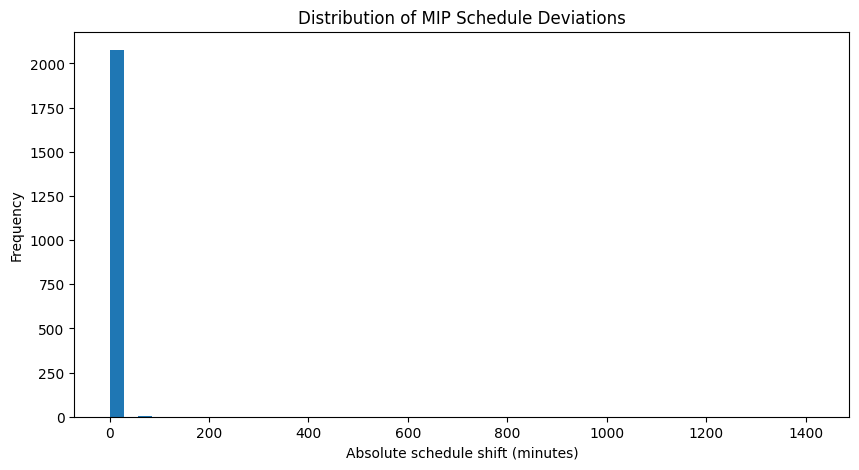

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


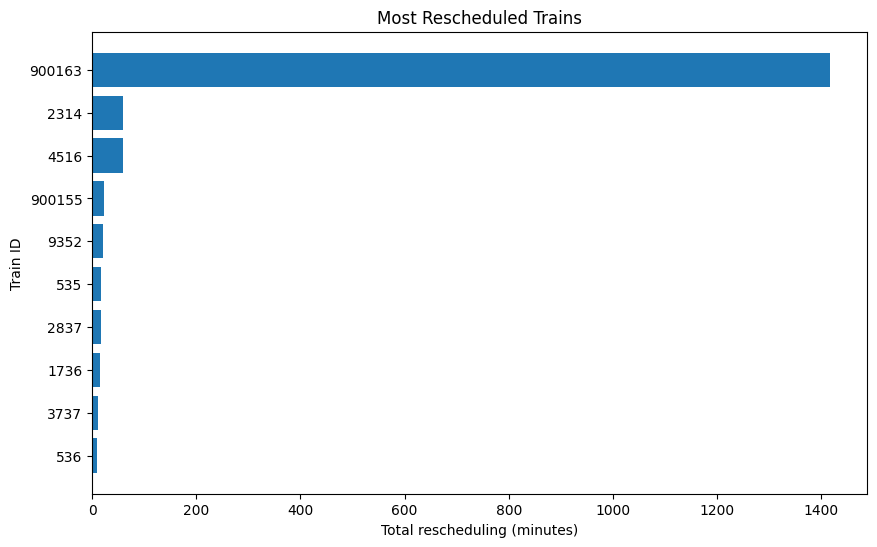


OBJECTIVE INFO
Objective value : 2069.2243130000043
Runtime          : 0.30 sec


In [7]:
# ============================================================
# COMPREHENSIVE MIP SCHEDULE ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# CHECK
# ============================================================

if not hasattr(simulator, "_solutions"):
    raise ValueError(
        "simulator._solutions bestaat niet. "
        "Heb je optie 3 correct toegevoegd?"
    )

if len(simulator._solutions) == 0:
    raise ValueError(
        "Geen MIP-solutions opgeslagen in simulator._solutions"
    )


# ============================================================
# SELECT SOLUTION
# ============================================================

# Laatste oplossing
solution = simulator._solutions[-1]

# Of:
# solution = simulator._solutions[0]
# solution = simulator._solutions[i]


# ============================================================
# BUILD SEGMENT-LEVEL ANALYSIS TABLE
# ============================================================

rows = []

for train_id, train in trains.items():

    for seg in train.path:

        planned_entry = timetable.scheduled_entry(train_id, seg)
        planned_exit  = timetable.scheduled_exit(train_id, seg)

        mip_entry = solution.entry.get((train_id, seg))
        mip_exit  = solution.exit.get((train_id, seg))

        if mip_entry is None or mip_exit is None:
            continue

        entry_shift = mip_entry - planned_entry
        exit_shift  = mip_exit  - planned_exit

        abs_shift = max(
            abs(entry_shift),
            abs(exit_shift),
        )

        rows.append({
            "train_id": train_id,
            "train_type": train.train_type.value,
            "segment": seg,

            "planned_entry": planned_entry,
            "mip_entry": mip_entry,

            "planned_exit": planned_exit,
            "mip_exit": mip_exit,

            "entry_shift_sec": entry_shift,
            "exit_shift_sec": exit_shift,

            "entry_shift_min": entry_shift / 60,
            "exit_shift_min": exit_shift / 60,

            "abs_shift_sec": abs_shift,
            "abs_shift_min": abs_shift / 60,
        })

df_schedule = pd.DataFrame(rows)


# ============================================================
# GLOBAL SUMMARY
# ============================================================

print("\n==================================================")
print("GLOBAL SUMMARY")
print("==================================================")

print(f"Total segment decisions: {len(df_schedule):,}")

print(
    f"Average absolute shift: "
    f"{df_schedule['abs_shift_min'].mean():.2f} min"
)

print(
    f"Median absolute shift: "
    f"{df_schedule['abs_shift_min'].median():.2f} min"
)

print(
    f"Maximum shift: "
    f"{df_schedule['abs_shift_min'].max():.2f} min"
)

print(
    f"95th percentile shift: "
    f"{df_schedule['abs_shift_min'].quantile(0.95):.2f} min"
)


# ============================================================
# MOST RESCHEDULED TRAINS
# ============================================================

train_summary = (
    df_schedule
    .groupby("train_id")
    .agg(
        train_type=("train_type", "first"),

        avg_shift_min=("abs_shift_min", "mean"),
        max_shift_min=("abs_shift_min", "max"),

        total_shift_min=("abs_shift_min", "sum"),

        n_changed_segments=(
            "abs_shift_sec",
            lambda x: (x > 1).sum()
        ),

        n_segments=("segment", "count"),
    )
    .reset_index()
)

train_summary["share_changed"] = (
    train_summary["n_changed_segments"]
    / train_summary["n_segments"]
)

train_summary = train_summary.sort_values(
    "total_shift_min",
    ascending=False,
)

print("\n==================================================")
print("TRAINS WITH LARGEST TOTAL RESCHEDULING")
print("==================================================")

display(train_summary.head(20))


# ============================================================
# MOST MODIFIED SEGMENTS
# ============================================================

segment_summary = (
    df_schedule
    .groupby("segment")
    .agg(
        avg_shift_min=("abs_shift_min", "mean"),
        max_shift_min=("abs_shift_min", "max"),
        total_shift_min=("abs_shift_min", "sum"),
        affected_trains=("train_id", "nunique"),
    )
    .reset_index()
)

segment_summary = segment_summary.sort_values(
    "total_shift_min",
    ascending=False,
)

print("\n==================================================")
print("MOST IMPACTED SEGMENTS")
print("==================================================")

display(segment_summary.head(20))


# ============================================================
# PASSENGER VS FREIGHT
# ============================================================

type_summary = (
    df_schedule
    .groupby("train_type")
    .agg(
        avg_shift_min=("abs_shift_min", "mean"),
        median_shift_min=("abs_shift_min", "median"),
        max_shift_min=("abs_shift_min", "max"),
        total_shift_min=("abs_shift_min", "sum"),
        n_segments=("segment", "count"),
    )
)

print("\n==================================================")
print("PASSENGER VS FREIGHT")
print("==================================================")

display(type_summary)


# ============================================================
# MOST EXTREME MODIFICATIONS
# ============================================================

extreme_changes = (
    df_schedule
    .sort_values("abs_shift_sec", ascending=False)
)

print("\n==================================================")
print("MOST EXTREME SINGLE SEGMENT MODIFICATIONS")
print("==================================================")

display(
    extreme_changes[
        [
            "train_id",
            "train_type",
            "segment",
            "entry_shift_min",
            "exit_shift_min",
            "abs_shift_min",
        ]
    ].head(30)
)


# ============================================================
# STABILITY / NERVOUSNESS ANALYSIS
# ============================================================

print("\n==================================================")
print("SCHEDULE STABILITY ANALYSIS")
print("==================================================")

n_changed = (df_schedule["abs_shift_sec"] > 1).sum()

share_changed = n_changed / len(df_schedule)

print(f"Changed segment decisions : {n_changed:,}")
print(f"Share changed             : {share_changed:.2%}")

large_changes = (df_schedule["abs_shift_min"] > 5).sum()

print(f"Changes > 5 min           : {large_changes:,}")

very_large_changes = (df_schedule["abs_shift_min"] > 15).sum()

print(f"Changes > 15 min          : {very_large_changes:,}")


# ============================================================
# HISTOGRAM OF SHIFTS
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    df_schedule["abs_shift_min"],
    bins=50,
)

plt.xlabel("Absolute schedule shift (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of MIP Schedule Deviations")

plt.show()


# ============================================================
# TOP 10 RESCHEDULED TRAINS VISUALIZATION
# ============================================================

top_trains = (
    train_summary
    .head(10)
    .sort_values("total_shift_min")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_trains["train_id"].astype(str),
    top_trains["total_shift_min"],
)

plt.xlabel("Total rescheduling (minutes)")
plt.ylabel("Train ID")
plt.title("Most Rescheduled Trains")

plt.show()


# ============================================================
# OBJECTIVE INFO
# ============================================================

print("\n==================================================")
print("OBJECTIVE INFO")
print("==================================================")

if hasattr(solution, "objective"):
    print(f"Objective value : {solution.objective}")

if hasattr(solution, "runtime"):
    print(f"Runtime          : {solution.runtime:.2f} sec")

if hasattr(solution, "gap"):
    print(f"MIP gap          : {solution.gap:.4f}")


# ============================================================
# MULTI-SOLUTION EVOLUTION ANALYSIS
# ============================================================

if len(simulator._solutions) > 1:

    rows = []

    for i, sol in enumerate(simulator._solutions):

        shifts = []

        for (t, seg), arr in sol.entry.items():

            planned = timetable.scheduled_entry(t, seg)

            shifts.append(abs(arr - planned) / 60)

        rows.append({
            "iteration": i,
            "objective": getattr(sol, "objective", np.nan),
            "avg_shift_min": np.mean(shifts),
            "max_shift_min": np.max(shifts),
            "total_shift_min": np.sum(shifts),
        })

    df_evolution = pd.DataFrame(rows)

    print("\n==================================================")
    print("EVOLUTION OF SUCCESSIVE RESCHEDULES")
    print("==================================================")

    display(df_evolution)

    plt.figure(figsize=(10, 5))

    plt.plot(
        df_evolution["iteration"],
        df_evolution["total_shift_min"],
    )

    plt.xlabel("Reschedule iteration")
    plt.ylabel("Total schedule shift (minutes)")
    plt.title("Evolution of Rescheduling Intensity")

    plt.show()


# ============================================================
# OPTIONAL EXPORT
# ============================================================

# df_schedule.to_csv("schedule_analysis.csv", index=False)
# train_summary.to_csv("train_summary.csv", index=False)
# segment_summary.to_csv("segment_summary.csv", index=False)

In [8]:
# ============================================================
# COMPARE RESCHEDULED TIMES VS ORIGINAL TIMETABLE
# ============================================================
#
# Geeft voor elk herscheduled segment:
#   - originele timetable tijden
#   - rescheduled tijden
#   - vertragingen
#
# Werkt op:
#   solution.arrival
#   solution.departure
#
# ============================================================

import pandas as pd

# ============================================================
# BUILD COMPARISON TABLE
# ============================================================

rows = []

for (train_id, segment_id), new_entry in solution.entry.items():

    new_exit = solution.exit.get((train_id, segment_id))

    # originele timetable
    planned_entry = timetable.scheduled_entry(train_id, segment_id)
    planned_exit  = timetable.scheduled_exit(train_id, segment_id)

    rows.append({

        "TRAIN_NO": train_id,
        "SECTION": segment_id,

        # ORIGINAL
        "planned_entry": planned_entry,
        "planned_exit": planned_exit,

        # RESCHEDULED
        "rescheduled_entry": new_entry,
        "rescheduled_exit": new_exit,

        # DELAYS
        "entry_delay": (
            new_entry - planned_entry
            if new_entry is not None else None
        ),

        "exit_delay": (
            new_exit - planned_exit
            if new_exit is not None else None
        ),

        # RUNNING TIMES
        "planned_runtime": (
            planned_exit - planned_entry
        ),

        "rescheduled_runtime": (
            new_exit - new_entry
            if new_exit is not None else None
        ),

    })

comparison = pd.DataFrame(rows)

# ============================================================
# SORT
# ============================================================

comparison = comparison.sort_values(
    ["TRAIN_NO", "rescheduled_entry"]
).reset_index(drop=True)

# ============================================================
# DISPLAY
# ============================================================

pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)

display(comparison)

# ============================================================
# MOST DELAYED
# ============================================================

print("\n" + "=" * 100)
print("MOST DELAYED SEGMENTS")
print("=" * 100)

display(
    comparison.sort_values(
        "exit_delay",
        ascending=False
    ).head(50)
)

# ============================================================
# CHANGED RUNNING TIMES
# ============================================================

comparison["runtime_diff"] = (
    comparison["rescheduled_runtime"] -
    comparison["planned_runtime"]
)

print("\n" + "=" * 100)
print("BIGGEST RUNTIME CHANGES")
print("=" * 100)

display(
    comparison.sort_values(
        "runtime_diff",
        ascending=False
    ).head(50)
)

,TRAIN_NO,SECTION,planned_entry,planned_exit,rescheduled_entry,rescheduled_exit,entry_delay,exit_delay,planned_runtime,rescheduled_runtime
0,17,0-1:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK,51783.0,51903.0,51783.0,51903.0,0.0,0.0,120.0,120.0
1,17,BRUSSEL-KAPELLEKERK -- platform 4,51903.0,51904.0,51903.0,51904.0,0.0,0.0,1.0,1.0
2,17,0-1:BRUSSEL-KAPELLEKERK-BRUSSEL-CENTRAAL,51904.0,51963.0,51904.0,51963.0,0.0,0.0,59.0,59.0
3,17,BRUSSEL-CENTRAAL -- platform 5,51963.0,51964.0,51963.0,51964.0,0.0,0.0,1.0,1.0
4,17,0-1:BRUSSEL-CENTRAAL-BRUSSEL-CONGRES,51964.0,52083.0,51964.0,52083.0,0.0,0.0,119.0,119.0
...,...,...,...,...,...,...,...,...,...,...
2074,900180,50:BRUSSEL-NOORD-BOCKSTAEL,53823.0,54135.0,53823.0,54135.0,0.0,0.0,312.0,312.0
2075,900180,BOCKSTAEL,54135.0,54136.0,54135.0,54136.0,0.0,0.0,1.0,1.0
2076,900180,50:BOCKSTAEL-JETTE,54136.0,54292.0,54136.0,54292.0,0.0,0.0,156.0,156.0
2077,900180,JETTE,54292.0,54293.0,54292.0,54293.0,0.0,0.0,1.0,1.0



MOST DELAYED SEGMENTS


,TRAIN_NO,SECTION,planned_entry,planned_exit,rescheduled_entry,rescheduled_exit,entry_delay,exit_delay,planned_runtime,rescheduled_runtime
2071,900163,28(1):BRUSSEL-WEST-BRUSSEL-ZUID,50842.0,51232.0,50842.0,136263.0,0.0,85031.0,390.0,85421.0
1711,4516,BRUSSEL-ZUID -- IC 05: CHARLEROI-CENTRAL -> AN...,62043.0,62283.0,62043.0,65883.0,0.0,3600.0,240.0,3840.0
949,2314,BRUSSEL-ZUID -- IC 23-2: OOSTENDE -> BRUSSELS ...,62283.0,62463.0,62283.0,66063.0,0.0,3600.0,180.0,3780.0
2062,900155,BRUSSEL-WEST,57081.0,57082.0,57272.0,57363.0,191.0,281.0,1.0,91.0
2063,900155,28(1):BRUSSEL-WEST-BRUSSEL-ZUID,57082.0,57472.0,57363.0,57753.0,281.0,281.0,390.0,390.0
1999,900083,36N:SCHAARBEEK-BRUSSEL-NOORD,55443.0,55677.0,55677.0,55911.0,234.0,234.0,234.0,234.0
2059,900155,28(1):THURN EN TAXIS-SIMONIS,56692.0,56925.0,56883.0,57116.0,191.0,191.0,233.0,233.0
2061,900155,28(1):SIMONIS-BRUSSEL-WEST,56926.0,57081.0,57117.0,57272.0,191.0,191.0,155.0,155.0
2058,900155,THURN EN TAXIS,56691.0,56692.0,56691.0,56883.0,0.0,191.0,1.0,192.0
2060,900155,SIMONIS,56925.0,56926.0,57116.0,57117.0,191.0,191.0,1.0,1.0



BIGGEST RUNTIME CHANGES


,TRAIN_NO,SECTION,planned_entry,planned_exit,rescheduled_entry,rescheduled_exit,entry_delay,exit_delay,planned_runtime,rescheduled_runtime,runtime_diff
2071,900163,28(1):BRUSSEL-WEST-BRUSSEL-ZUID,50842.0,51232.0,50842.0,136263.0,0.0,85031.0,390.0,85421.0,85031.0
949,2314,BRUSSEL-ZUID -- IC 23-2: OOSTENDE -> BRUSSELS ...,62283.0,62463.0,62283.0,66063.0,0.0,3600.0,180.0,3780.0,3600.0
1711,4516,BRUSSEL-ZUID -- IC 05: CHARLEROI-CENTRAL -> AN...,62043.0,62283.0,62043.0,65883.0,0.0,3600.0,240.0,3840.0,3600.0
2058,900155,THURN EN TAXIS,56691.0,56692.0,56691.0,56883.0,0.0,191.0,1.0,192.0,191.0
959,2337,BRUSSEL-ZUID -- IC 23-2: BRUSSELS AIRPORT - ZA...,52443.0,52623.0,52443.0,52733.0,0.0,110.0,180.0,290.0,110.0
2047,900146,SCHAARBEEK,55351.0,55352.0,55351.0,55443.0,0.0,91.0,1.0,92.0,91.0
2062,900155,BRUSSEL-WEST,57081.0,57082.0,57272.0,57363.0,191.0,281.0,1.0,91.0,90.0
252,1736,BRUSSEL-NOORD -- platform 9,54483.0,54663.0,54483.0,54733.0,0.0,70.0,180.0,250.0,70.0
1996,900071,SCHAARBEEK,51894.0,51895.0,51894.0,51963.0,0.0,68.0,1.0,69.0,68.0
717,2164,50:SINT-AGATHA-BERCHEM-JETTE,53823.0,54003.0,53823.0,54063.0,0.0,60.0,180.0,240.0,60.0


In [9]:
# ============================================================
# NERVOUSNESS BETWEEN SUCCESSIVE MIP SCHEDULES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if len(simulator._solutions) < 2:
    raise ValueError("Minstens 2 MIP solutions nodig")


rows = []

for k in range(1, len(simulator._solutions)):

    prev_sol = simulator._solutions[k - 1]
    curr_sol = simulator._solutions[k]

    total_change = 0
    max_change = 0
    n_changed = 0

    all_pairs = set(prev_sol.entry.keys()) | set(curr_sol.entry.keys())

    for key in all_pairs:

        prev_arr = prev_sol.entry.get(key)
        curr_arr = curr_sol.entry.get(key)

        if prev_arr is None or curr_arr is None:
            continue

        diff = abs(curr_arr - prev_arr)

        total_change += diff
        max_change = max(max_change, diff)

        if diff > 1:
            n_changed += 1

    rows.append({
        "iteration": k,
        "total_change_min": total_change / 60,
        "avg_change_min": (
            total_change / max(1, n_changed)
        ) / 60,
        "max_change_min": max_change / 60,
        "n_changed_segments": n_changed,
    })

df_nervousness = pd.DataFrame(rows)

print("==================================================")
print("SUCCESSIVE MIP NERVOUSNESS")
print("==================================================")

display(df_nervousness)


# ============================================================
# VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    df_nervousness["iteration"],
    df_nervousness["total_change_min"],
)

plt.xlabel("MIP iteration")
plt.ylabel("Total schedule change (minutes)")
plt.title("Nervousness Between Successive MIP Schedules")

plt.show()

ValueError: Minstens 2 MIP solutions nodig

In [ ]:
simulator._solutions

[Solution(status=optimal, objective=387.57, runtime=0.00s),
 Solution(status=optimal, objective=2018.55, runtime=0.04s),
 Solution(status=optimal, objective=2030.37, runtime=0.05s),
 Solution(status=optimal, objective=2691.37, runtime=0.06s),
 Solution(status=optimal, objective=1964.03, runtime=0.17s),
 Solution(status=optimal, objective=873.40, runtime=0.12s),
 Solution(status=optimal, objective=852.27, runtime=0.18s),
 Solution(status=optimal, objective=1139.09, runtime=0.18s),
 Solution(status=optimal, objective=1607.80, runtime=0.18s),
 Solution(status=optimal, objective=1601.70, runtime=0.16s),
 Solution(status=optimal, objective=1477.00, runtime=0.19s),
 Solution(status=optimal, objective=1319.94, runtime=0.15s),
 Solution(status=optimal, objective=1138.16, runtime=0.17s),
 Solution(status=optimal, objective=1595.90, runtime=0.16s),
 Solution(status=optimal, objective=1533.20, runtime=0.18s),
 Solution(status=optimal, objective=775.24, runtime=0.16s),
 Solution(status=optimal, ob

In [ ]:
display(compare_train(2045, state, timetable, trains))

,segment,scheduled_entry,actual_entry,entry_delay,scheduled_exit,actual_exit,exit_delay
0,36:SCHAARBEEK-BRUSSEL-NOORD,86103.0,86223.0,120.0,86283.0,86403.0,120.0
1,BRUSSEL-NOORD -- platform 9,86283.0,86403.0,120.0,86523.0,86643.0,120.0
2,0-4:BRUSSEL-NOORD-BRUSSEL-CONGRES,86523.0,86643.0,120.0,86643.0,86763.0,120.0
3,BRUSSEL-CONGRES -- platform 3,86643.0,86763.0,120.0,86644.0,86764.0,120.0
4,0-4:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,86644.0,86764.0,120.0,86763.0,86883.0,120.0
5,BRUSSEL-CENTRAAL -- platform 6,86763.0,86883.0,120.0,86823.0,86943.0,120.0
6,0-4:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,86823.0,86943.0,120.0,86943.0,87063.0,120.0
7,BRUSSEL-KAPELLEKERK -- platform 1,86943.0,87063.0,120.0,86944.0,87064.0,120.0
8,0-4:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,86944.0,87064.0,120.0,87063.0,87183.0,120.0


In [ ]:
display(compare_train(11, state, timetable, trains))

,segment,scheduled_entry,actual_entry,entry_delay,scheduled_exit,actual_exit,exit_delay
0,0-1:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK,22863.0,22863.0,0.0,22983.0,22983.0,0.0
1,BRUSSEL-KAPELLEKERK -- platform 1,22983.0,22983.0,0.0,22984.0,22984.0,0.0
2,0-1:BRUSSEL-KAPELLEKERK-BRUSSEL-CENTRAAL,22984.0,22984.0,0.0,23043.0,23043.0,0.0
3,BRUSSEL-CENTRAAL -- platform 3,23043.0,23043.0,0.0,23044.0,23044.0,0.0
4,0-1:BRUSSEL-CENTRAAL-BRUSSEL-CONGRES,23044.0,23044.0,0.0,23103.0,23104.0,1.0
5,BRUSSEL-CONGRES -- platform 1,23103.0,23104.0,1.0,23104.0,23105.0,1.0
6,0-1:BRUSSEL-CONGRES-BRUSSEL-NOORD,23104.0,23105.0,1.0,23223.0,23224.0,1.0
7,BRUSSEL-NOORD -- platform 4,23223.0,23224.0,1.0,23343.0,23344.0,1.0
8,36N:BRUSSEL-NOORD-SCHAARBEEK,23343.0,23344.0,1.0,23523.0,23524.0,1.0


In [ ]:
display(compare_train(18, state, timetable, trains))

,segment,scheduled_entry,actual_entry,entry_delay,scheduled_exit,actual_exit,exit_delay
0,36N:SCHAARBEEK-BRUSSEL-NOORD,33663.0,33663.0,0.0,33843.0,33843.0,0.0
1,BRUSSEL-NOORD -- platform 3,33843.0,33843.0,0.0,33963.0,33963.0,0.0
2,0-2:BRUSSEL-NOORD-BRUSSEL-CONGRES,33963.0,33963.0,0.0,34083.0,34083.0,0.0
3,BRUSSEL-CONGRES -- platform 4,34083.0,34083.0,0.0,34084.0,34084.0,0.0
4,0-2:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,34084.0,34084.0,0.0,34143.0,34143.0,0.0
5,BRUSSEL-CENTRAAL -- platform 2,34143.0,34143.0,0.0,34144.0,34144.0,0.0
6,0-2:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,34144.0,34144.0,0.0,34263.0,34263.0,0.0
7,BRUSSEL-KAPELLEKERK -- platform 4,34263.0,34263.0,0.0,34264.0,34264.0,0.0
8,0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,34264.0,34264.0,0.0,34383.0,34383.0,0.0


END DELAY STATISTICS

Passenger:
count    1028.000000
mean        8.433852
std        39.958456
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       409.000000
Name: entry_delay, dtype: float64

Freight:
count    182.000000
mean      27.532967
std       75.845849
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      537.000000
Name: entry_delay, dtype: float64


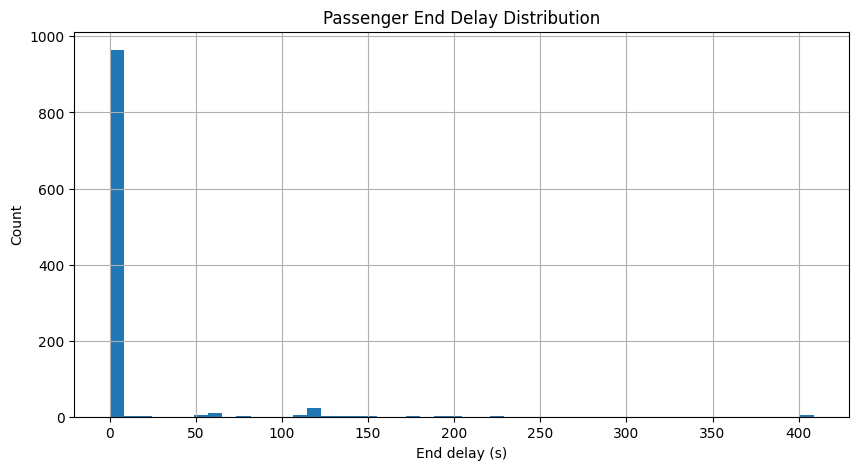

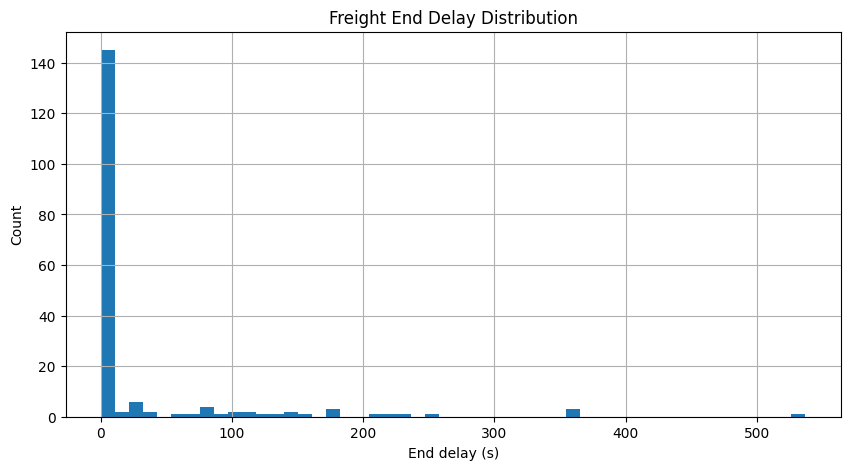


INTERMEDIATE DELAY STATISTICS

Passenger intermediate:
count    9044.000000
mean        4.330827
std        24.816973
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       228.000000
Name: entry_delay, dtype: float64

Freight intermediate:
count    552.000000
mean      14.012681
std       75.483257
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      537.000000
Name: entry_delay, dtype: float64


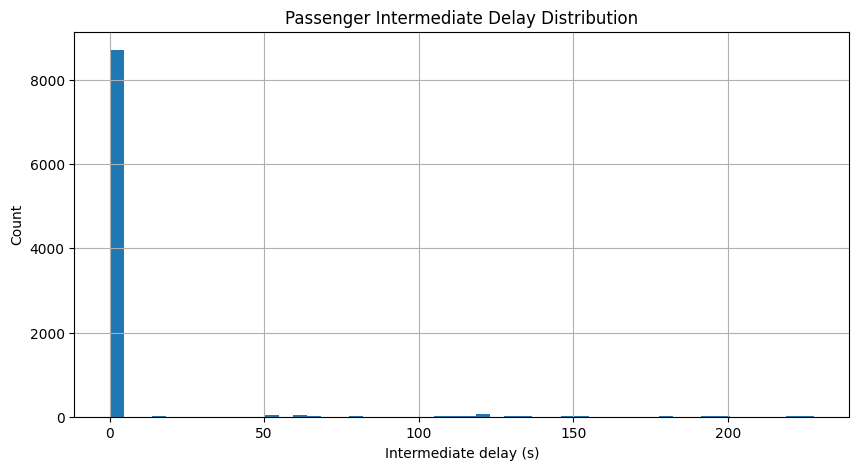

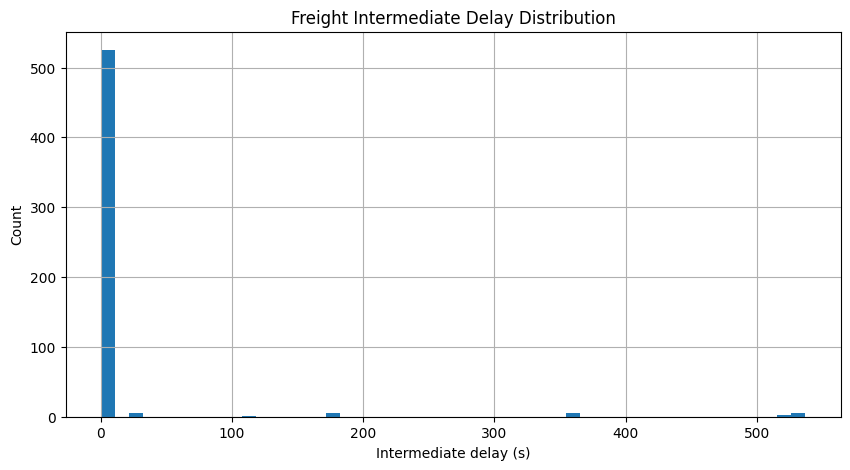


SIGN ANALYSIS

Passenger END
-------------
Negative :      0 (  0.0%)
Zero     :    960 ( 93.4%)
Positive :     68 (  6.6%)

Freight END
-----------
Negative :      0 (  0.0%)
Zero     :    144 ( 79.1%)
Positive :     38 ( 20.9%)

Passenger INTERMEDIATE
----------------------
Negative :      0 (  0.0%)
Zero     :   8694 ( 96.1%)
Positive :    350 (  3.9%)

Freight INTERMEDIATE
--------------------
Negative :      0 (  0.0%)
Zero     :    525 ( 95.1%)
Positive :     27 (  4.9%)


In [ ]:
# ------------------------------------------------------------
# DELAY DISTRIBUTION ANALYSIS
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import pandas as pd


# ============================================================
# 1. END DELAY DISTRIBUTIONS
# ============================================================

# Laatste segment per trein
last_seg = (
    df.sort_values("planned_entry")
      .groupby(["train_id", "train_type"])
      .last()
      .reset_index()
)

pass_end = last_seg[last_seg["train_type"] == "P"]["entry_delay"]
freight_end = last_seg[last_seg["train_type"] == "F"]["entry_delay"]

print("==================================================")
print("END DELAY STATISTICS")
print("==================================================")

print("\nPassenger:")
print(pass_end.describe())

print("\nFreight:")
print(freight_end.describe())


# Histogram passenger
plt.figure(figsize=(10, 5))
plt.hist(pass_end, bins=50)
plt.title("Passenger End Delay Distribution")
plt.xlabel("End delay (s)")
plt.ylabel("Count")
plt.grid(True)
plt.show()


# Histogram freight
plt.figure(figsize=(10, 5))
plt.hist(freight_end, bins=50)
plt.title("Freight End Delay Distribution")
plt.xlabel("End delay (s)")
plt.ylabel("Count")
plt.grid(True)
plt.show()


# ============================================================
# 2. INTERMEDIATE DELAY DISTRIBUTIONS
# ============================================================

# Intermediate = alle segmenten behalve laatste segment
last_pairs = set(
    zip(last_seg["train_id"], last_seg["segment_id"])
)

intermediate_df = df[
    ~df.apply(
        lambda r: (r["train_id"], r["segment_id"]) in last_pairs,
        axis=1
    )
]

pass_inter = intermediate_df[
    intermediate_df["train_type"] == "P"
]["entry_delay"]

freight_inter = intermediate_df[
    intermediate_df["train_type"] == "F"
]["entry_delay"]

print("\n==================================================")
print("INTERMEDIATE DELAY STATISTICS")
print("==================================================")

print("\nPassenger intermediate:")
print(pass_inter.describe())

print("\nFreight intermediate:")
print(freight_inter.describe())


# Histogram passenger intermediate
plt.figure(figsize=(10, 5))
plt.hist(pass_inter, bins=50)
plt.title("Passenger Intermediate Delay Distribution")
plt.xlabel("Intermediate delay (s)")
plt.ylabel("Count")
plt.grid(True)
plt.show()


# Histogram freight intermediate
plt.figure(figsize=(10, 5))
plt.hist(freight_inter, bins=50)
plt.title("Freight Intermediate Delay Distribution")
plt.xlabel("Intermediate delay (s)")
plt.ylabel("Count")
plt.grid(True)
plt.show()


# ============================================================
# 3. NEGATIVE VS POSITIVE DELAYS
# ============================================================

def summarize_signs(series, label):

    neg = (series < 0).sum()
    zero = (series == 0).sum()
    pos = (series > 0).sum()

    total = len(series)

    print(f"\n{label}")
    print("-" * len(label))

    print(f"Negative : {neg:6d} ({100*neg/total:5.1f}%)")
    print(f"Zero     : {zero:6d} ({100*zero/total:5.1f}%)")
    print(f"Positive : {pos:6d} ({100*pos/total:5.1f}%)")


print("\n==================================================")
print("SIGN ANALYSIS")
print("==================================================")

summarize_signs(pass_end, "Passenger END")
summarize_signs(freight_end, "Freight END")

summarize_signs(pass_inter, "Passenger INTERMEDIATE")
summarize_signs(freight_inter, "Freight INTERMEDIATE")

In [ ]:
# ------------------------------------------------------------
# TOP DELAYED TRAINS
# ------------------------------------------------------------

top_pass = (
    last_seg[last_seg["train_type"] == "P"]
    .sort_values("entry_delay", ascending=False)
    .head(10)
)

top_freight = (
    last_seg[last_seg["train_type"] == "F"]
    .sort_values("entry_delay", ascending=False)
    .head(10)
)

print("TOP PASSENGER")
display(
    top_pass[
        ["train_id", "segment_id", "entry_delay"]
    ]
)

print("\nTOP FREIGHT")
display(
    top_freight[
        ["train_id", "segment_id", "entry_delay"]
    ]
)

TOP PASSENGER


,train_id,segment_id,entry_delay
816,3859,28(1):BRUSSEL-WEST-BRUSSEL-ZUID,409.0
815,3858,28(1):BRUSSEL-WEST-BRUSSEL-ZUID,409.0
812,3855,28(1):BRUSSEL-WEST-BRUSSEL-ZUID,409.0
822,3865,28(1):BRUSSEL-WEST-BRUSSEL-ZUID,409.0
819,3862,28(1):BRUSSEL-WEST-BRUSSEL-ZUID,409.0
30,427,0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,228.0
1000,9426,0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,228.0
983,9328,0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,223.0
104,1529,0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,198.0
106,1531,50C:BRUSSEL-ZUID-ANDERLECHT,192.0



TOP FREIGHT


,train_id,segment_id,entry_delay
1205,900177,28(1):BRUSSEL-WEST-BRUSSEL-ZUID,537.0
1161,900133,36N:SCHAARBEEK-BRUSSEL-NOORD,363.0
1085,900057,36N:SCHAARBEEK-BRUSSEL-NOORD,363.0
1177,900149,28(1):BRUSSEL-WEST-BRUSSEL-ZUID,358.0
1069,900041,36N:SCHAARBEEK-BRUSSEL-NOORD,248.0
1111,900083,36N:SCHAARBEEK-BRUSSEL-NOORD,234.0
1052,900024,36N:SCHAARBEEK-BRUSSEL-NOORD,219.0
1135,900107,36N:SCHAARBEEK-BRUSSEL-NOORD,207.0
1158,900130,28(1):BRUSSEL-WEST-BRUSSEL-ZUID,179.0
1043,900015,36N:SCHAARBEEK-BRUSSEL-NOORD,179.0


In [ ]:
# ------------------------------------------------------------
# MEAN DELAY PER SEGMENT
# ------------------------------------------------------------

segment_delay = (
    df.groupby(["segment_id", "train_type"])["entry_delay"]
      .mean()
      .reset_index()
)

print("PASSENGER")
display(
    segment_delay[
        segment_delay["train_type"] == "P"
    ]
    .sort_values("entry_delay", ascending=False)
    .head(20)
)

print("\nFREIGHT")
display(
    segment_delay[
        segment_delay["train_type"] == "F"
    ]
    .sort_values("entry_delay", ascending=False)
    .head(20)
)

PASSENGER


,segment_id,train_type,entry_delay
40,28(1):BRUSSEL-WEST-BRUSSEL-ZUID,P,146.071429
144,SIMONIS -- platform 2,P,79.071429
112,BRUSSEL-WEST -- platform 2,P,79.071429
51,28(1):THURN EN TAXIS-SIMONIS,P,79.071429
46,28(1):SIMONIS-BRUSSEL-WEST,P,79.071429
121,BRUSSEL-ZUID -- IC 12: KORTRIJK -> WELKENRAEDT,P,60.000000
80,60:JETTE-ZELLIK,P,35.803922
134,BRUSSEL-ZUID -- L B1-2: ANTWERPEN-CENTRAAL -> ...,P,31.588235
115,BRUSSEL-ZUID -- IC 03: BLANKENBERGE -> GENK,P,24.000000
8,0-2:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK,P,20.000000



FREIGHT


,segment_id,train_type,entry_delay
59,36N:SCHAARBEEK-BRUSSEL-NOORD,F,45.247059
79,60:JETTE-ZELLIK,F,40.000000
39,28(1):BRUSSEL-WEST-BRUSSEL-ZUID,F,34.645161
45,28(1):SIMONIS-BRUSSEL-WEST,F,34.645161
50,28(1):THURN EN TAXIS-SIMONIS,F,34.645161
52,28:SCHAARBEEK-THURN EN TAXIS,F,34.645161
145,THURN EN TAXIS,F,16.029851
142,SIMONIS,F,16.029851
110,BRUSSEL-WEST,F,16.029851
141,SCHAARBEEK,F,10.462687


In [ ]:
# ------------------------------------------------------------
# DELAY RATIO WITHOUT SCHAARBEEK -> BRUSSEL-NOORD
# ------------------------------------------------------------

import pandas as pd


# ============================================================
# 1. REMOVE TARGET SEGMENT
# ============================================================

excluded_segment = "36N:SCHAARBEEK-BRUSSEL-NOORD"

df_filtered = df[
    df["segment_id"] != excluded_segment
].copy()


# ============================================================
# 2. RECOMPUTE END DELAYS
# ============================================================

# Nieuwe "laatste segmenten" nadat het segment verwijderd is
last_seg_filtered = (
    df_filtered
    .sort_values("planned_entry")
    .groupby(["train_id", "train_type"])
    .last()
    .reset_index()
)

pass_mask = last_seg_filtered["train_type"] == "P"
freight_mask = last_seg_filtered["train_type"] == "F"

ted_p = (
    last_seg_filtered[pass_mask]["entry_delay"]
    .clip(lower=0)
    .sum()
)

ted_f = (
    last_seg_filtered[freight_mask]["entry_delay"]
    .clip(lower=0)
    .sum()
)

n_pass = pass_mask.sum()
n_freight = freight_mask.sum()

avg_p = ted_p / n_pass
avg_f = ted_f / n_freight

delay_ratio_filtered = avg_f / avg_p


# ============================================================
# 3. ORIGINAL METRICS
# ============================================================

orig = compute_metrics(df)

print("==================================================")
print("ORIGINAL")
print("==================================================")

print(f"TED_passenger : {orig['TED_passenger']:.1f}")
print(f"TED_freight   : {orig['TED_freight']:.1f}")
print(f"delay_ratio   : {orig['delay_ratio']:.3f}")

print("\n==================================================")
print("WITHOUT SCHAARBEEK -> BRUSSEL-NOORD")
print("==================================================")

print(f"TED_passenger : {ted_p:.1f}")
print(f"TED_freight   : {ted_f:.1f}")
print(f"delay_ratio   : {delay_ratio_filtered:.3f}")


# ============================================================
# 4. IMPACT ANALYSIS
# ============================================================

print("\n==================================================")
print("IMPACT")
print("==================================================")

delta = delay_ratio_filtered - orig["delay_ratio"]

print(f"Absolute change : {delta:+.3f}")
print(f"Relative change : {100 * delta / orig['delay_ratio']:+.1f}%")

ORIGINAL
TED_passenger : 8670.0
TED_freight   : 5011.0
delay_ratio   : 3.265

WITHOUT SCHAARBEEK -> BRUSSEL-NOORD
TED_passenger : 8670.0
TED_freight   : 1346.0
delay_ratio   : 1.200

IMPACT
Absolute change : -2.065
Relative change : -63.2%


BASELINE
delay_ratio = 3.265

TOP IMPACT SEGMENTS


,segment_id,new_delay_ratio,delta_ratio,abs_impact
0,36N:SCHAARBEEK-BRUSSEL-NOORD,1.199962,-2.064616,2.064616
1,25:BRUSSEL-NOORD-SCHAARBEEK,4.455077,1.190499,1.190499
2,28(1):BRUSSEL-WEST-BRUSSEL-ZUID,3.660617,0.396039,0.396039
3,50C:BRUSSEL-ZUID-ANDERLECHT,3.428902,0.164324,0.164324
4,26:SCHAARBEEK-BRUSSEL-SCHUMAN,3.375870,0.111292,0.111292
5,0-6:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,3.332614,0.068036,0.068036
6,60:JETTE-ZELLIK,3.212459,-0.052119,0.052119
7,26:BRUSSEL-SCHUMAN-SCHAARBEEK,3.300851,0.036273,0.036273
8,50C:ANDERLECHT-BRUSSEL-ZUID,3.288007,0.023429,0.023429
9,50A:BRUSSEL-ZUID-ANDERLECHT,3.261402,-0.003176,0.003176


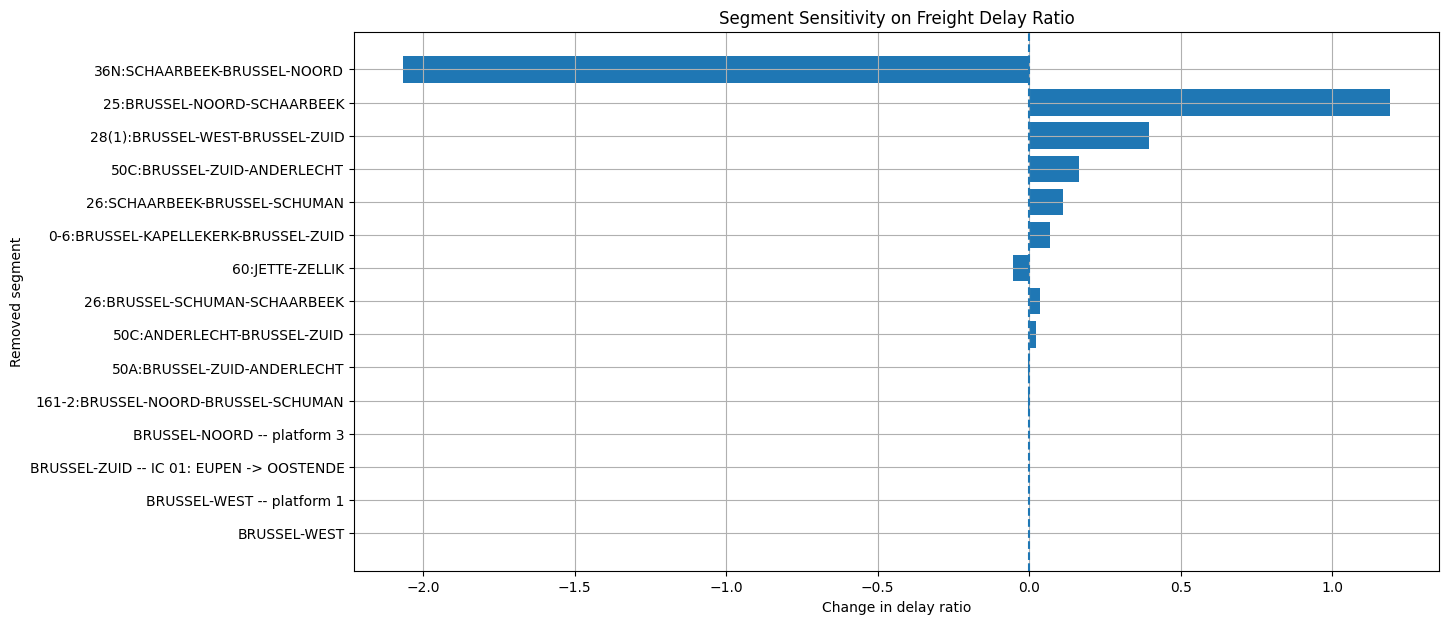

In [ ]:
# ------------------------------------------------------------
# SEGMENT SENSITIVITY ANALYSIS
# ------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# BASELINE
# ============================================================

baseline = compute_metrics(df)

baseline_ratio = baseline["delay_ratio"]

print("==================================================")
print("BASELINE")
print("==================================================")

print(f"delay_ratio = {baseline_ratio:.3f}")


# ============================================================
# FUNCTION
# ============================================================

def recompute_delay_ratio_without_segment(df, excluded_segment):

    # verwijder segment
    df_filtered = df[df["segment_id"] != excluded_segment].copy()

    # bepaal nieuw laatste segment per trein
    last_seg = (
        df_filtered
        .sort_values("planned_entry")
        .groupby(["train_id", "train_type"])
        .last()
        .reset_index()
    )

    pass_mask = last_seg["train_type"] == "P"
    freight_mask = last_seg["train_type"] == "F"

    ted_p = (
        last_seg[pass_mask]["entry_delay"]
        .clip(lower=0)
        .sum()
    )

    ted_f = (
        last_seg[freight_mask]["entry_delay"]
        .clip(lower=0)
        .sum()
    )

    n_pass = pass_mask.sum()
    n_freight = freight_mask.sum()

    if n_pass == 0 or n_freight == 0:
        return None

    avg_p = ted_p / n_pass

    if avg_p <= 0:
        return None

    avg_f = ted_f / n_freight

    return avg_f / avg_p


# ============================================================
# ANALYZE ALL SEGMENTS
# ============================================================

results = []

segments = sorted(df["segment_id"].unique())

for seg in segments:

    try:
        new_ratio = recompute_delay_ratio_without_segment(df, seg)

        if new_ratio is None:
            continue

        delta = new_ratio - baseline_ratio

        results.append({
            "segment_id": seg,
            "new_delay_ratio": new_ratio,
            "delta_ratio": delta,
            "abs_impact": abs(delta),
        })

    except Exception as e:

        print(f"FAILED for {seg}: {e}")


# ============================================================
# RESULTS TABLE
# ============================================================

sensitivity_df = (
    pd.DataFrame(results)
    .sort_values("abs_impact", ascending=False)
    .reset_index(drop=True)
)

print("\n==================================================")
print("TOP IMPACT SEGMENTS")
print("==================================================")

display(sensitivity_df.head(20))


# ============================================================
# PLOT
# ============================================================

top_plot = sensitivity_df.head(15)

plt.figure(figsize=(14, 7))

plt.barh(
    top_plot["segment_id"][::-1],
    top_plot["delta_ratio"][::-1],
)

plt.axvline(0, linestyle="--")

plt.xlabel("Change in delay ratio")
plt.ylabel("Removed segment")
plt.title("Segment Sensitivity on Freight Delay Ratio")

plt.grid(True)

plt.show()

BASELINE
TED_combined = 13681.0

TOP IMPACT SEGMENTS ON TOTAL END DELAY


,segment_id,new_TED_combined,delta_TED,abs_impact
0,36N:SCHAARBEEK-BRUSSEL-NOORD,10016.0,-3665.0,3665.0
1,28(1):BRUSSEL-WEST-BRUSSEL-ZUID,12743.0,-938.0,938.0
2,50C:BRUSSEL-ZUID-ANDERLECHT,13451.0,-230.0,230.0
3,0-6:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,13504.0,-177.0,177.0
4,60:JETTE-ZELLIK,13601.0,-80.0,80.0
5,25:BRUSSEL-NOORD-SCHAARBEEK,13610.0,-71.0,71.0
6,BRUSSEL-NOORD -- platform 7,13681.0,0.0,0.0
7,BRUSSEL-NOORD -- platform 12,13681.0,0.0,0.0
8,BRUSSEL-NOORD -- platform 2,13681.0,0.0,0.0
9,BRUSSEL-NOORD -- platform 3,13681.0,0.0,0.0


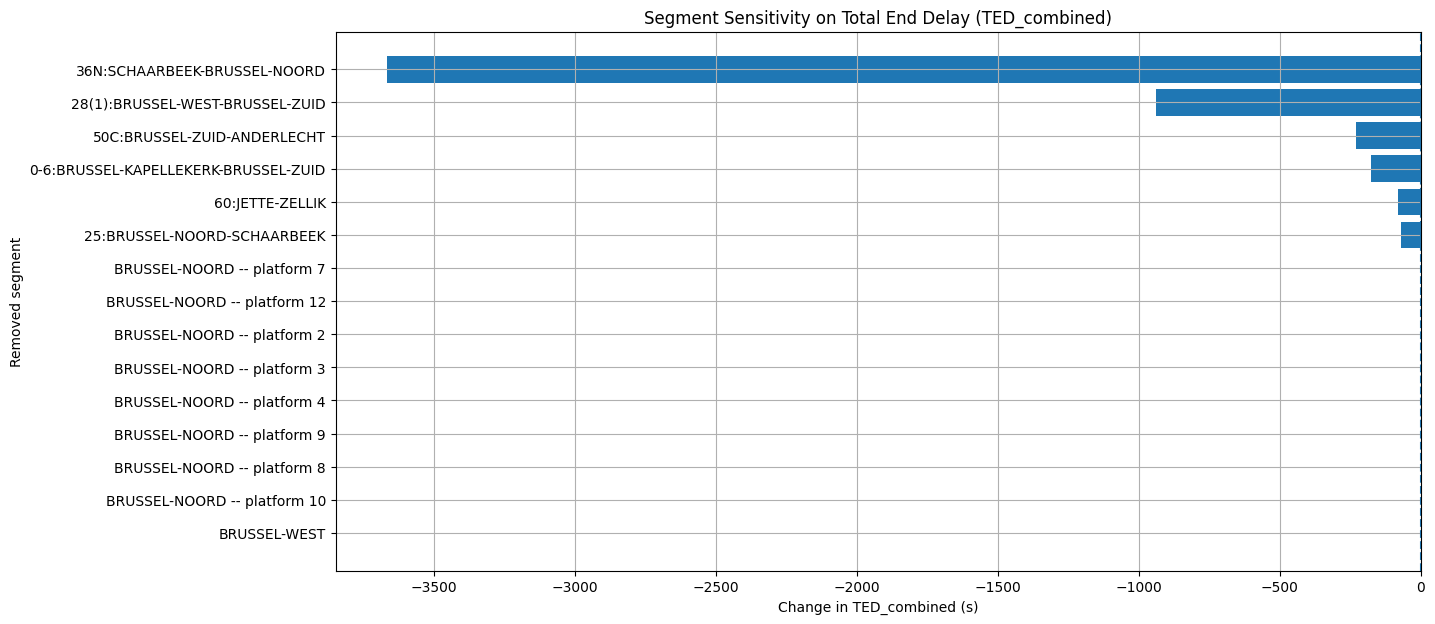

In [ ]:
# ------------------------------------------------------------
# SEGMENT SENSITIVITY ANALYSIS ON TOTAL END DELAY
# ------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# BASELINE
# ============================================================

baseline = compute_metrics(df)

baseline_ted = baseline["TED_combined"]

print("==================================================")
print("BASELINE")
print("==================================================")

print(f"TED_combined = {baseline_ted:.1f}")


# ============================================================
# FUNCTION
# ============================================================

def recompute_ted_without_segment(df, excluded_segment):

    # verwijder segment
    df_filtered = df[df["segment_id"] != excluded_segment].copy()

    # nieuw laatste segment per trein
    last_seg = (
        df_filtered
        .sort_values("planned_entry")
        .groupby(["train_id", "train_type"])
        .last()
        .reset_index()
    )

    ted_p = (
        last_seg[last_seg["train_type"] == "P"]["entry_delay"]
        .clip(lower=0)
        .sum()
    )

    ted_f = (
        last_seg[last_seg["train_type"] == "F"]["entry_delay"]
        .clip(lower=0)
        .sum()
    )

    return ted_p + ted_f


# ============================================================
# ANALYZE ALL SEGMENTS
# ============================================================

results = []

segments = sorted(df["segment_id"].unique())

for seg in segments:

    try:

        new_ted = recompute_ted_without_segment(df, seg)

        delta = new_ted - baseline_ted

        results.append({
            "segment_id": seg,
            "new_TED_combined": new_ted,
            "delta_TED": delta,
            "abs_impact": abs(delta),
        })

    except Exception as e:

        print(f"FAILED for {seg}: {e}")


# ============================================================
# RESULTS TABLE
# ============================================================

sensitivity_ted_df = (
    pd.DataFrame(results)
    .sort_values("abs_impact", ascending=False)
    .reset_index(drop=True)
)

print("\n==================================================")
print("TOP IMPACT SEGMENTS ON TOTAL END DELAY")
print("==================================================")

display(sensitivity_ted_df.head(20))


# ============================================================
# PLOT
# ============================================================

top_plot = sensitivity_ted_df.head(15)

plt.figure(figsize=(14, 7))

plt.barh(
    top_plot["segment_id"][::-1],
    top_plot["delta_TED"][::-1],
)

plt.axvline(0, linestyle="--")

plt.xlabel("Change in TED_combined (s)")
plt.ylabel("Removed segment")

plt.title(
    "Segment Sensitivity on Total End Delay (TED_combined)"
)

plt.grid(True)

plt.show()

TOP SEGMENTS BY MEAN DELAY


,Freight,Passenger,Combined
segment_id,,,
28(1):BRUSSEL-WEST-BRUSSEL-ZUID,34.645161,146.071429,180.716590
28(1):THURN EN TAXIS-SIMONIS,34.645161,79.071429,113.716590
28(1):SIMONIS-BRUSSEL-WEST,34.645161,79.071429,113.716590
SIMONIS -- platform 2,0.000000,79.071429,79.071429
BRUSSEL-WEST -- platform 2,0.000000,79.071429,79.071429
60:JETTE-ZELLIK,40.000000,35.803922,75.803922
36N:SCHAARBEEK-BRUSSEL-NOORD,45.247059,18.118881,63.365940
BRUSSEL-ZUID -- IC 12: KORTRIJK -> WELKENRAEDT,0.000000,60.000000,60.000000
28:SCHAARBEEK-THURN EN TAXIS,34.645161,0.000000,34.645161


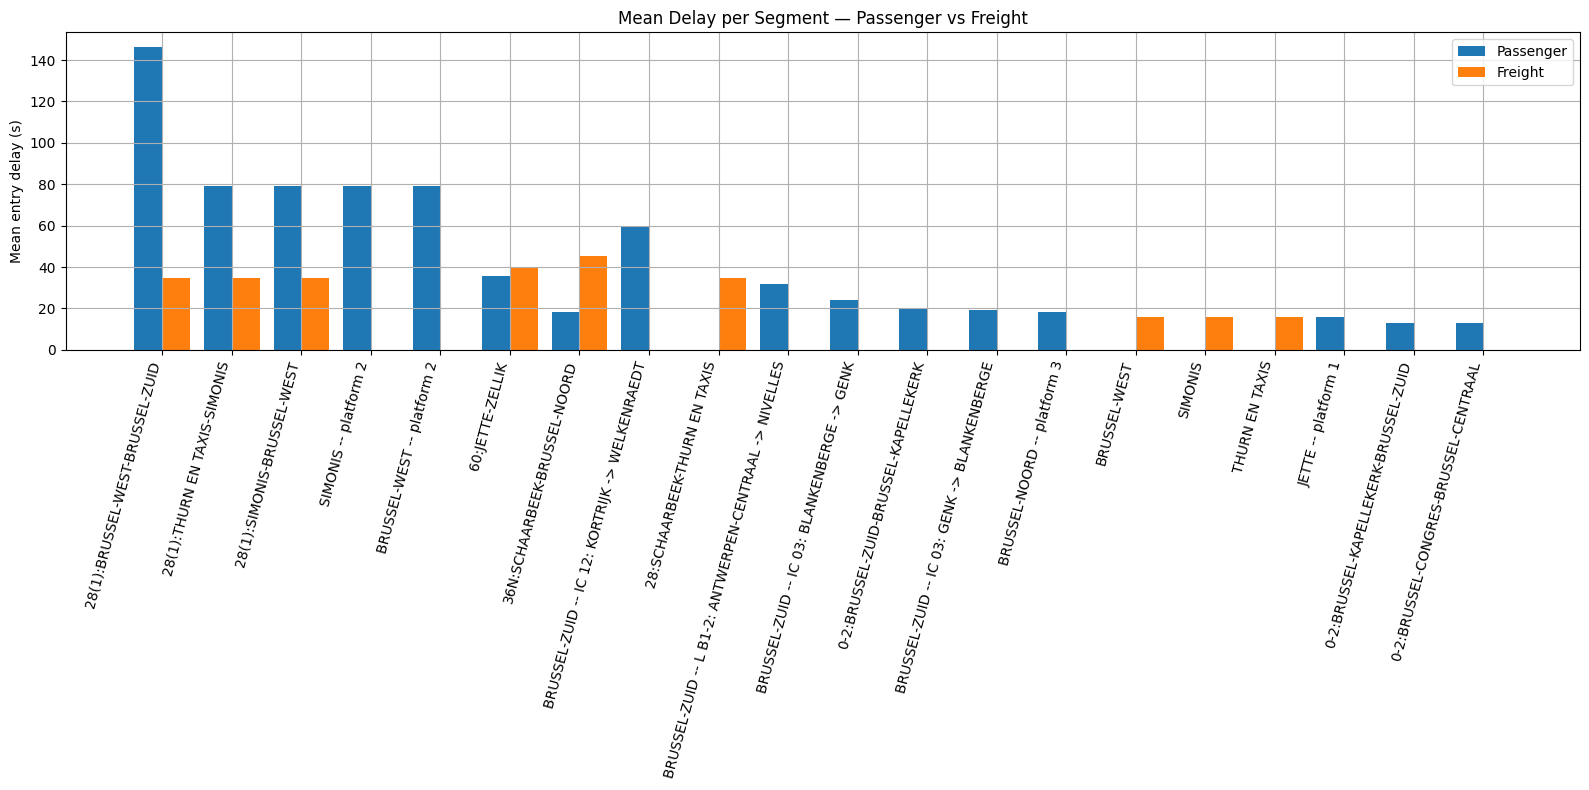

In [ ]:
# ------------------------------------------------------------
# MEAN DELAY PER SEGMENT (PASSENGER VS FREIGHT)
# ------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# MEAN DELAY PER SEGMENT & TRAIN TYPE
# ============================================================

segment_delay = (
    df.groupby(["segment_id", "train_type"])["entry_delay"]
      .mean()
      .reset_index()
)

# pivot zodat passenger/freight aparte kolommen worden
pivot = (
    segment_delay
    .pivot(
        index="segment_id",
        columns="train_type",
        values="entry_delay"
    )
    .fillna(0)
)

pivot.columns.name = None

# hernoem kolommen indien aanwezig
pivot = pivot.rename(columns={
    "P": "Passenger",
    "F": "Freight",
})

# totale gemiddelde delay
pivot["Combined"] = pivot.sum(axis=1)

# sorteer op totale impact
pivot = (
    pivot.sort_values("Combined", ascending=False)
         .head(20)
)

print("==================================================")
print("TOP SEGMENTS BY MEAN DELAY")
print("==================================================")

display(pivot)


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(16, 8))

x = range(len(pivot))

width = 0.4

ax.bar(
    [i - width/2 for i in x],
    pivot["Passenger"],
    width=width,
    label="Passenger",
)

ax.bar(
    [i + width/2 for i in x],
    pivot["Freight"],
    width=width,
    label="Freight",
)

ax.set_xticks(list(x))
ax.set_xticklabels(
    pivot.index,
    rotation=75,
    ha="right"
)

ax.set_ylabel("Mean entry delay (s)")
ax.set_title("Mean Delay per Segment — Passenger vs Freight")

ax.legend()

ax.grid(True)

plt.tight_layout()
plt.show()

TOP FINAL SEGMENTS BY MEAN END DELAY


,Freight,Passenger,Combined
segment_id,,,
28(1):BRUSSEL-WEST-BRUSSEL-ZUID,34.645161,146.071429,180.716590
60:JETTE-ZELLIK,40.000000,35.803922,75.803922
36N:SCHAARBEEK-BRUSSEL-NOORD,45.247059,0.000000,45.247059
0-2:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,0.000000,13.648810,13.648810
124:BRUSSEL-ZUID-VORST-OOST,0.000000,10.265625,10.265625
50C:BRUSSEL-ZUID-ANDERLECHT,0.000000,7.819277,7.819277
0-6:BRUSSEL-KAPELLEKERK-BRUSSEL-ZUID,0.000000,5.960000,5.960000
161-2:BRUSSEL-NOORD-BRUSSEL-SCHUMAN,0.000000,4.084746,4.084746
161-2:BRUSSEL-NOORD-SCHAARBEEK,0.000000,3.750000,3.750000


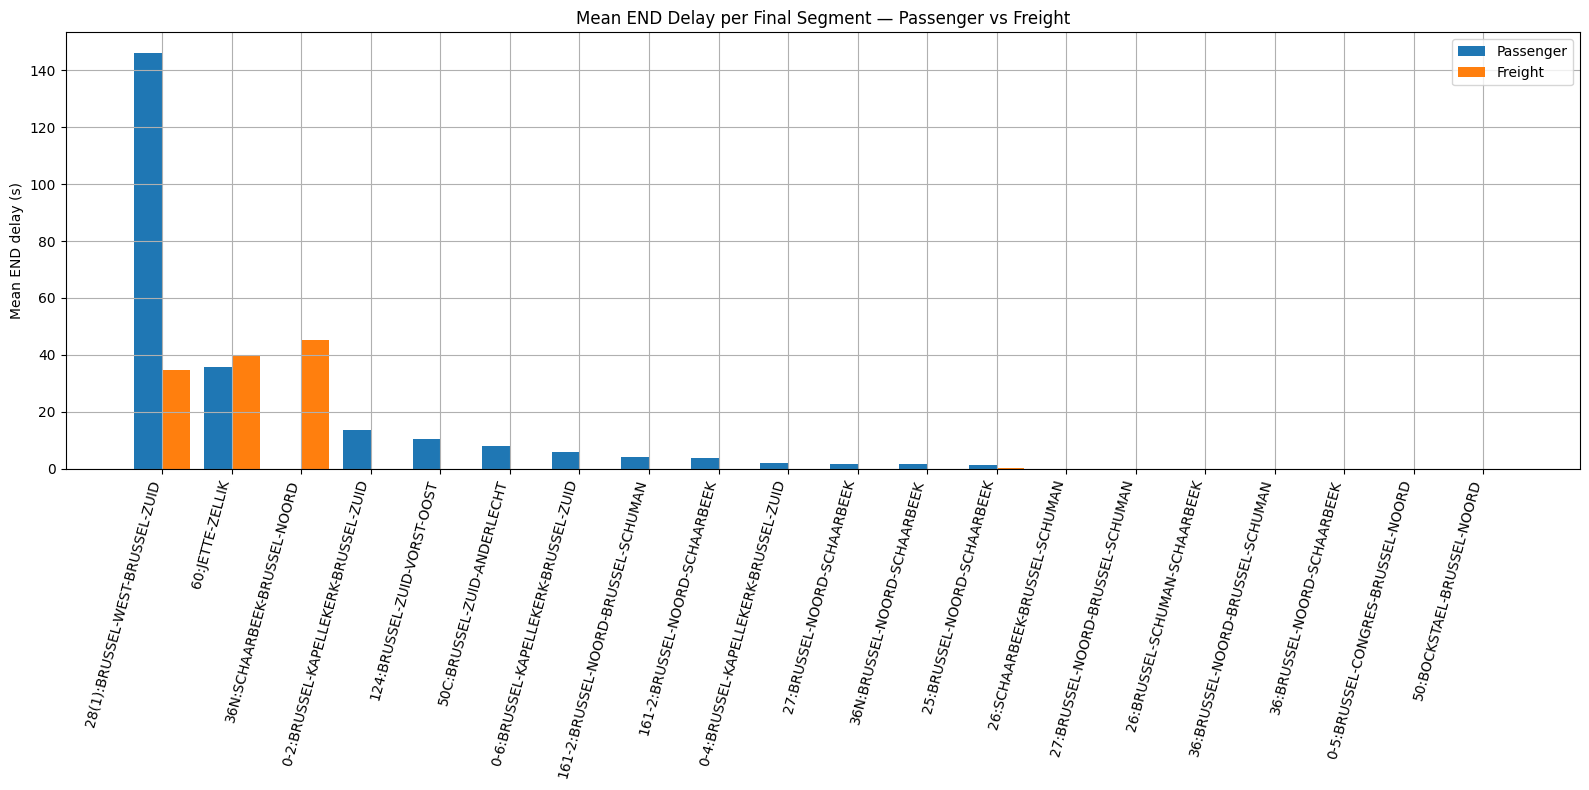

In [ ]:
# ------------------------------------------------------------
# END DELAY PER SEGMENT (PASSENGER VS FREIGHT)
# ------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# LAST SEGMENT PER TRAIN
# ============================================================

last_seg = (
    df.sort_values("planned_entry")
      .groupby(["train_id", "train_type"])
      .last()
      .reset_index()
)


# ============================================================
# MEAN END DELAY PER FINAL SEGMENT
# ============================================================

end_delay = (
    last_seg
    .groupby(["segment_id", "train_type"])["entry_delay"]
    .mean()
    .reset_index()
)

pivot = (
    end_delay
    .pivot(
        index="segment_id",
        columns="train_type",
        values="entry_delay"
    )
    .fillna(0)
)

pivot.columns.name = None

pivot = pivot.rename(columns={
    "P": "Passenger",
    "F": "Freight",
})

pivot["Combined"] = pivot.sum(axis=1)

pivot = (
    pivot
    .sort_values("Combined", ascending=False)
    .head(20)
)

print("==================================================")
print("TOP FINAL SEGMENTS BY MEAN END DELAY")
print("==================================================")

display(pivot)


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(16, 8))

x = range(len(pivot))

width = 0.4

ax.bar(
    [i - width/2 for i in x],
    pivot["Passenger"],
    width=width,
    label="Passenger",
)

ax.bar(
    [i + width/2 for i in x],
    pivot["Freight"],
    width=width,
    label="Freight",
)

ax.set_xticks(list(x))

ax.set_xticklabels(
    pivot.index,
    rotation=75,
    ha="right"
)

ax.set_ylabel("Mean END delay (s)")
ax.set_title("Mean END Delay per Final Segment — Passenger vs Freight")

ax.legend()

ax.grid(True)

plt.tight_layout()
plt.show()

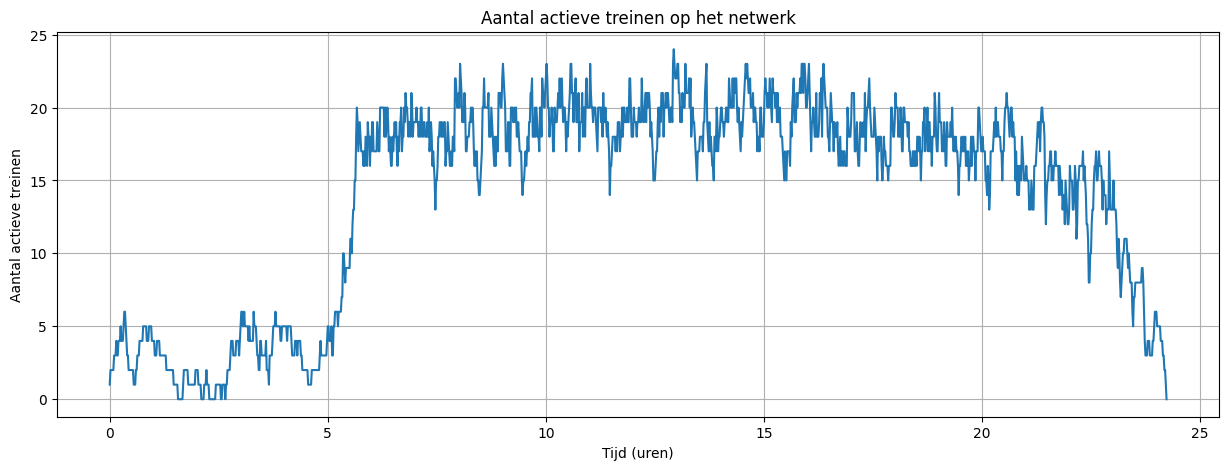

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Intervallen bepalen
# ============================================================

intervals = []

simulation_end = state.current_time

for train_id, seg_data in state._actual.items():

    entries = []
    exits   = []

    for seg_id, times in seg_data.items():

        entry, exit_ = times

        if entry is not None:
            entries.append(entry)

        if exit_ is not None:
            exits.append(exit_)

    if not entries:
        continue

    start = min(entries)

    if exits:
        end = max(exits)
    else:
        end = simulation_end

    intervals.append((start, end))

# ============================================================
# Tijdas (elke minuut)
# ============================================================

max_time = max(end for _, end in intervals)

times = np.arange(
    0,
    max_time + 60,
    60,  # 1 minuut resolutie
)

# ============================================================
# Actieve treinen tellen
# ============================================================

active_counts = []

for t in times:

    active = sum(
        start <= t <= end
        for start, end in intervals
    )

    active_counts.append(active)

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(15, 5))

plt.plot(
    times / 3600,
    active_counts,
)

plt.xlabel("Tijd (uren)")
plt.ylabel("Aantal actieve treinen")
plt.title("Aantal actieve treinen op het netwerk")

plt.grid(True)

plt.show()

In [ ]:
print("Aantal treinen totaal:", len(state._trains))
print("Aantal treinen ooit gestart:", len(state._actual))
print("Aantal actieve treinen nu:", len(state.active_train_ids()))
max_active = max(active_counts)

print("Maximum simultaan actieve treinen:", max_active)

Aantal treinen totaal: 1210
Aantal treinen ooit gestart: 1210
Aantal actieve treinen nu: 0
Maximum simultaan actieve treinen: 24


In [ ]:

# ============================================================
# COMPARE GOLD TIMETABLE VS SAMPLING DISTRIBUTIONS
# ============================================================

import pandas as pd
import numpy as np

from data.timetable import load_gold
from data.running_distributions import _load

# ============================================================
# LOAD DATA
# ============================================================

N_FREIGHT = 182

gold = load_gold("combined", N_FREIGHT)
dist = _load()

# ============================================================
# KEEP ONLY BETWEEN-STATION SEGMENTS
# ============================================================

between = gold[gold["SOURCE"] != gold["TARGET"]].copy()

# running time uit gold timetable
between["running_time"] = (
    between["EXIT_SECONDS"] -
    between["ENTRY_SECONDS"]
)

between = between[between["running_time"] > 0]

# ============================================================
# TIMETABLE STATISTICS
# ============================================================

tt_stats = (
    between.groupby("SECTION")["running_time"]
    .agg(
        timetable_mean="mean",
        timetable_median="median",
        timetable_std="std",
        timetable_min="min",
        timetable_max="max",
        timetable_n="count",
    )
    .reset_index()
)

# ============================================================
# SAMPLE DISTRIBUTION STATISTICS
# ============================================================

rows = []

for section, section_data in dist.items():

    all_samples = []

    for train_type, dyn_data in section_data.items():

        for dynamics, period_data in dyn_data.items():

            for period, cell in period_data.items():

                real = cell.get("real", [])

                if len(real) > 0:
                    all_samples.extend(real)

    if len(all_samples) == 0:
        continue

    rows.append({
        "SECTION": section,
        "sample_mean": np.mean(all_samples),
        "sample_median": np.median(all_samples),
        "sample_std": np.std(all_samples),
        "sample_min": np.min(all_samples),
        "sample_max": np.max(all_samples),
        "sample_n": len(all_samples),
    })

sample_stats = pd.DataFrame(rows)

# ============================================================
# MERGE
# ============================================================

comparison = tt_stats.merge(
    sample_stats,
    on="SECTION",
    how="outer"
)

# ============================================================
# DIFFERENCES
# ============================================================

comparison["mean_diff_signed"] = (
    comparison["sample_mean"] -
    comparison["timetable_mean"]
)

comparison["mean_diff_abs"] = (
    comparison["mean_diff_signed"]
).abs()

comparison["median_diff_signed"] = (
    comparison["sample_median"] -
    comparison["timetable_median"]
)

comparison["median_diff_abs"] = (
    comparison["median_diff_signed"]
).abs()

comparison["mean_ratio"] = (
    comparison["sample_mean"] /
    comparison["timetable_mean"]
)

comparison["median_ratio"] = (
    comparison["sample_median"] /
    comparison["timetable_median"]
)

# ============================================================
# SORT
# ============================================================

comparison_sorted = comparison.sort_values(
    by=["mean_diff_abs", "median_diff_abs"],
    ascending=False
)

# ============================================================
# DISPLAY OPTIONS
# ============================================================

pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)

cols = [
    "SECTION",

    "timetable_mean",
    "sample_mean",
    "mean_diff_signed",
    "mean_diff_abs",
    "mean_ratio",

    "timetable_median",
    "sample_median",
    "median_diff_signed",
    "median_diff_abs",
    "median_ratio",

    "timetable_n",
    "sample_n",
]

# ============================================================
# MAIN OVERVIEW
# ============================================================

print("\n" + "=" * 100)
print("FULL COMPARISON")
print("=" * 100)

display(
    comparison_sorted[cols]
    .round(2)
    .reset_index(drop=True)
)

# ============================================================
# TOP DIFFERENCES
# ============================================================

print("\n" + "=" * 100)
print("TOP 25 BIGGEST DIFFERENCES")
print("=" * 100)

display(
    comparison_sorted[cols]
    .head(25)
    .round(2)
    .reset_index(drop=True)
)

# ============================================================
# ONLY IN GOLD
# ============================================================

print("\n" + "=" * 100)
print("SECTIONS ONLY IN GOLD TIMETABLE")
print("=" * 100)

only_gold = comparison[
    comparison["sample_mean"].isna()
]

display(
    only_gold[[
        "SECTION",
        "timetable_mean",
        "timetable_median",
        "timetable_n",
    ]]
    .sort_values("timetable_n", ascending=False)
    .reset_index(drop=True)
)

# ============================================================
# ONLY IN DISTRIBUTIONS
# ============================================================

print("\n" + "=" * 100)
print("SECTIONS ONLY IN RUNNING DISTRIBUTIONS")
print("=" * 100)

only_dist = comparison[
    comparison["timetable_mean"].isna()
]

display(
    only_dist[[
        "SECTION",
        "sample_mean",
        "sample_median",
        "sample_n",
    ]]
    .sort_values("sample_n", ascending=False)
    .reset_index(drop=True)
)

INFO:data.timetable:Gold geladen (combined): 1210 treinen, 10806 segmenten
INFO:data.running_distributions:Rijtijdverdelingen geladen: 100 secties



FULL COMPARISON


,SECTION,timetable_mean,sample_mean,mean_diff_signed,mean_diff_abs,mean_ratio,timetable_median,sample_median,median_diff_signed,median_diff_abs,median_ratio,timetable_n,sample_n
0,28(1):THURN EN TAXIS-SIMONIS,210.76,91.37,-119.39,119.39,0.43,233.0,95.0,-138.0,138.0,0.41,45.0,3935.0
1,36N:BRUSSEL-NOORD-BOCKSTAEL,240.00,299.31,59.31,59.31,1.25,240.0,267.0,27.0,27.0,1.11,1.0,130.0
2,36:BRUSSEL-NOORD-BRUSSEL-SCHUMAN,420.00,478.76,58.76,58.76,1.14,420.0,453.0,33.0,33.0,1.08,1.0,190.0
3,28(1):BRUSSEL-ZUID-BRUSSEL-WEST,363.53,306.04,-57.49,57.49,0.84,390.0,292.0,-98.0,98.0,0.75,51.0,4102.0
4,50C:BRUSSEL-ZUID-ANDERLECHT,290.86,235.40,-55.46,55.46,0.81,300.0,231.0,-69.0,69.0,0.77,87.0,24468.0
5,25:BRUSSEL-NOORD-SCHAARBEEK,204.30,151.83,-52.47,52.47,0.74,180.0,149.0,-31.0,31.0,0.83,183.0,24610.0
6,27:BRUSSEL-NOORD-BRUSSEL-SCHUMAN,420.00,462.31,42.31,42.31,1.10,420.0,443.0,23.0,23.0,1.05,8.0,1466.0
7,28(1):BRUSSEL-WEST-BRUSSEL-ZUID,362.00,320.57,-41.43,41.43,0.89,390.0,297.0,-93.0,93.0,0.76,45.0,3880.0
8,0-6:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,103.77,65.03,-38.74,38.74,0.63,120.0,63.0,-57.0,57.0,0.52,114.0,26843.0
9,28(1):SIMONIS-BRUSSEL-WEST,143.76,106.13,-37.63,37.63,0.74,155.0,108.0,-47.0,47.0,0.70,45.0,3935.0



TOP 25 BIGGEST DIFFERENCES


,SECTION,timetable_mean,sample_mean,mean_diff_signed,mean_diff_abs,mean_ratio,timetable_median,sample_median,median_diff_signed,median_diff_abs,median_ratio,timetable_n,sample_n
0,28(1):THURN EN TAXIS-SIMONIS,210.76,91.37,-119.39,119.39,0.43,233.0,95.0,-138.0,138.0,0.41,45.0,3935.0
1,36N:BRUSSEL-NOORD-BOCKSTAEL,240.00,299.31,59.31,59.31,1.25,240.0,267.0,27.0,27.0,1.11,1.0,130.0
2,36:BRUSSEL-NOORD-BRUSSEL-SCHUMAN,420.00,478.76,58.76,58.76,1.14,420.0,453.0,33.0,33.0,1.08,1.0,190.0
3,28(1):BRUSSEL-ZUID-BRUSSEL-WEST,363.53,306.04,-57.49,57.49,0.84,390.0,292.0,-98.0,98.0,0.75,51.0,4102.0
4,50C:BRUSSEL-ZUID-ANDERLECHT,290.86,235.40,-55.46,55.46,0.81,300.0,231.0,-69.0,69.0,0.77,87.0,24468.0
5,25:BRUSSEL-NOORD-SCHAARBEEK,204.30,151.83,-52.47,52.47,0.74,180.0,149.0,-31.0,31.0,0.83,183.0,24610.0
6,27:BRUSSEL-NOORD-BRUSSEL-SCHUMAN,420.00,462.31,42.31,42.31,1.10,420.0,443.0,23.0,23.0,1.05,8.0,1466.0
7,28(1):BRUSSEL-WEST-BRUSSEL-ZUID,362.00,320.57,-41.43,41.43,0.89,390.0,297.0,-93.0,93.0,0.76,45.0,3880.0
8,0-6:BRUSSEL-CENTRAAL-BRUSSEL-KAPELLEKERK,103.77,65.03,-38.74,38.74,0.63,120.0,63.0,-57.0,57.0,0.52,114.0,26843.0
9,28(1):SIMONIS-BRUSSEL-WEST,143.76,106.13,-37.63,37.63,0.74,155.0,108.0,-47.0,47.0,0.70,45.0,3935.0



SECTIONS ONLY IN GOLD TIMETABLE


,SECTION,timetable_mean,timetable_median,timetable_n
0,28:THURN EN TAXIS-SCHAARBEEK,413.388889,413.0,36.0
1,28:SCHAARBEEK-THURN EN TAXIS,413.064516,413.0,31.0
2,26:SCHAARBEEK-BRUSSEL-SCHUMAN,560.333333,560.0,6.0
3,26:BRUSSEL-SCHUMAN-SCHAARBEEK,560.500000,560.5,2.0



SECTIONS ONLY IN RUNNING DISTRIBUTIONS


,SECTION,sample_mean,sample_median,sample_n
0,BRUSSEL-NOORD,151.219497,139.0,223689.0
1,BRUSSEL-CENTRAAL,94.880420,93.0,220036.0
2,BRUSSEL-ZUID,236.592159,221.0,81159.0
3,JETTE,94.029668,85.0,41358.0
4,BOCKSTAEL,80.915005,70.0,25884.0
5,BRUSSEL-WEST,60.029031,57.0,7337.0
6,BRUSSEL-CONGRES,55.596965,52.0,7116.0
7,SIMONIS,58.687992,51.0,3048.0
8,THURN EN TAXIS,55.042384,49.0,3020.0
9,BRUSSEL-KAPELLEKERK,59.254438,55.0,2704.0


In [ ]:
# ============================================================
# CHECK WITHIN-STATION-PASSINGS FOR FREIGHT TRAINS
# ============================================================
#
# Doel:
#   Controleren of WITHIN-STATION-PASSING segmenten
#   correct in de freight timetable staan.
#
# We controleren:
#
# 1. ENTRY <= EXIT
# 2. passing duration == PASSING_DURATION_PASSENGER
# 3. volgend segment begint exact na de passing
# 4. passing ligt tussen twee between-station segmenten
# 5. stationnamen zijn consistent
# 6. geen vreemde overlaps/gaps
#
# ============================================================

import pandas as pd
import numpy as np

from data.timetable import load_gold
from config.settings import PASSING_DURATION_PASSENGER

# ============================================================
# LOAD
# ============================================================

N_FREIGHT = 182

df = load_gold("combined", N_FREIGHT).copy()

# ============================================================
# SORT
# ============================================================

df = df.sort_values(
    ["TRAIN_NO", "ENTRY_SECONDS"]
).reset_index(drop=True)

# ============================================================
# FILTER PASSINGS
# ============================================================

passings = df[
    df["TYPE"] == "WITHIN-STATION-PASSING"
].copy()

print("=" * 80)
print(f"N PASSING SEGMENTS: {len(passings)}")
print("=" * 80)

display(
    passings[[
        "TRAIN_NO",
        "SECTION",
        "SOURCE",
        "TARGET",
        "ENTRY_SECONDS",
        "EXIT_SECONDS",
    ]].head(20)
)

# ============================================================
# DURATION CHECK
# ============================================================

passings["duration"] = (
    passings["EXIT_SECONDS"] -
    passings["ENTRY_SECONDS"]
)

print("\n" + "=" * 80)
print("PASSING DURATIONS")
print("=" * 80)

display(
    passings["duration"]
    .describe()
)

# ============================================================
# WRONG DURATIONS
# ============================================================

wrong_duration = passings[
    ~np.isclose(
        passings["duration"],
        PASSING_DURATION_PASSENGER
    )
]

print("\n" + "=" * 80)
print("WRONG PASSING DURATIONS")
print("=" * 80)

print(f"N wrong durations: {len(wrong_duration)}")

display(
    wrong_duration[[
        "TRAIN_NO",
        "SECTION",
        "ENTRY_SECONDS",
        "EXIT_SECONDS",
        "duration",
    ]]
)

# ============================================================
# CHECK CONTINUITY WITH NEXT SEGMENT
# ============================================================

rows = []

for train_no, grp in df.groupby("TRAIN_NO"):

    grp = grp.sort_values("ENTRY_SECONDS").reset_index(drop=True)

    for i in range(len(grp) - 1):

        current = grp.iloc[i]
        nxt     = grp.iloc[i + 1]

        if current["TYPE"] != "WITHIN-STATION-PASSING":
            continue

        gap = (
            nxt["ENTRY_SECONDS"] -
            current["EXIT_SECONDS"]
        )

        rows.append({
            "TRAIN_NO": train_no,

            "passing_section": current["SECTION"],
            "next_section": nxt["SECTION"],

            "passing_exit": current["EXIT_SECONDS"],
            "next_entry": nxt["ENTRY_SECONDS"],

            "gap_after_passing": gap,

            "passing_source": current["SOURCE"],
            "next_source": nxt["SOURCE"],
            "next_target": nxt["TARGET"],

            "passing_type": current["TYPE"],
            "next_type": nxt["TYPE"],
        })

continuity = pd.DataFrame(rows)

print("\n" + "=" * 80)
print("GAP AFTER PASSING")
print("=" * 80)

display(
    continuity["gap_after_passing"]
    .describe()
)

# ============================================================
# BAD GAPS
# ============================================================

bad_gaps = continuity[
    continuity["gap_after_passing"] != 0
]

print("\n" + "=" * 80)
print("NON-ZERO GAPS AFTER PASSING")
print("=" * 80)

print(f"N bad gaps: {len(bad_gaps)}")

display(
    bad_gaps.sort_values(
        "gap_after_passing",
        ascending=False
    )
)

# ============================================================
# CHECK PREVIOUS/NEXT TYPES
# ============================================================

rows = []

for train_no, grp in df.groupby("TRAIN_NO"):

    grp = grp.sort_values("ENTRY_SECONDS").reset_index(drop=True)

    for i in range(1, len(grp) - 1):

        current = grp.iloc[i]

        if current["TYPE"] != "WITHIN-STATION-PASSING":
            continue

        prev_seg = grp.iloc[i - 1]
        next_seg = grp.iloc[i + 1]

        rows.append({

            "TRAIN_NO": train_no,

            "passing_section": current["SECTION"],

            "prev_type": prev_seg["TYPE"],
            "next_type": next_seg["TYPE"],

            "prev_section": prev_seg["SECTION"],
            "next_section": next_seg["SECTION"],

            "prev_target": prev_seg["TARGET"],
            "passing_station": current["SOURCE"],
            "next_source": next_seg["SOURCE"],

        })

context_df = pd.DataFrame(rows)

print("\n" + "=" * 80)
print("PASSING CONTEXT")
print("=" * 80)

display(context_df.head(30))

# ============================================================
# SUSPICIOUS CONTEXTS
# ============================================================

suspicious = context_df[
    (context_df["prev_type"] != "BETWEEN-STATION") |
    (context_df["next_type"] != "BETWEEN-STATION")
]

print("\n" + "=" * 80)
print("SUSPICIOUS PASSING CONTEXTS")
print("=" * 80)

print(f"N suspicious contexts: {len(suspicious)}")

display(suspicious)

# ============================================================
# CHECK STATION CONSISTENCY
# ============================================================

station_errors = context_df[
    (context_df["prev_target"] != context_df["passing_station"]) |
    (context_df["next_source"] != context_df["passing_station"])
]

print("\n" + "=" * 80)
print("STATION CONSISTENCY ERRORS")
print("=" * 80)

print(f"N station errors: {len(station_errors)}")

display(station_errors)

# ============================================================
# FULL TIMELINES OF PROBLEMATIC TRAINS
# ============================================================

problem_trains = sorted(set(
    wrong_duration["TRAIN_NO"].tolist()
    + bad_gaps["TRAIN_NO"].tolist()
    + suspicious["TRAIN_NO"].tolist()
    + station_errors["TRAIN_NO"].tolist()
))

print("\n" + "=" * 80)
print("PROBLEM TRAINS")
print("=" * 80)

print(problem_trains)

for train_no in problem_trains[:10]:

    print("\n" + "=" * 80)
    print(f"TRAIN {train_no}")
    print("=" * 80)

    timeline = df[
        df["TRAIN_NO"] == train_no
    ][[
        "SECTION",
        "TYPE",
        "SOURCE",
        "TARGET",
        "ENTRY_SECONDS",
        "EXIT_SECONDS",
    ]]

    display(timeline.reset_index(drop=True))

INFO:data.timetable:Gold geladen (combined): 1210 treinen, 10806 segmenten


N PASSING SEGMENTS: 2364


,TRAIN_NO,SECTION,SOURCE,TARGET,ENTRY_SECONDS,EXIT_SECONDS
3,10,BRUSSEL-CONGRES -- platform 1,BRUSSEL-CONGRES,BRUSSEL-CONGRES,77283,77284
5,10,BRUSSEL-CENTRAAL -- platform 5,BRUSSEL-CENTRAAL,BRUSSEL-CENTRAAL,77343,77344
7,10,BRUSSEL-KAPELLEKERK -- platform 4,BRUSSEL-KAPELLEKERK,BRUSSEL-KAPELLEKERK,77463,77464
10,11,BRUSSEL-KAPELLEKERK -- platform 1,BRUSSEL-KAPELLEKERK,BRUSSEL-KAPELLEKERK,22983,22984
12,11,BRUSSEL-CENTRAAL -- platform 3,BRUSSEL-CENTRAAL,BRUSSEL-CENTRAAL,23043,23044
14,11,BRUSSEL-CONGRES -- platform 1,BRUSSEL-CONGRES,BRUSSEL-CONGRES,23103,23104
21,12,BRUSSEL-CONGRES -- platform 2,BRUSSEL-CONGRES,BRUSSEL-CONGRES,70083,70084
23,12,BRUSSEL-CENTRAAL -- platform 6,BRUSSEL-CENTRAAL,BRUSSEL-CENTRAAL,70143,70144
25,12,BRUSSEL-KAPELLEKERK -- platform 1,BRUSSEL-KAPELLEKERK,BRUSSEL-KAPELLEKERK,70263,70264
28,13,BRUSSEL-KAPELLEKERK -- platform 3,BRUSSEL-KAPELLEKERK,BRUSSEL-KAPELLEKERK,30303,30304



PASSING DURATIONS


count    2364.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: duration, dtype: float64

...

,SECTION,TYPE,SOURCE,TARGET,ENTRY_SECONDS,EXIT_SECONDS
0,0-1:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK,SOURCE,BRUSSEL-ZUID,BRUSSEL-KAPELLEKERK,19563,19683
1,BRUSSEL-KAPELLEKERK -- platform 3,WITHIN-STATION-PASSING,BRUSSEL-KAPELLEKERK,BRUSSEL-KAPELLEKERK,19683,19684
2,0-1:BRUSSEL-KAPELLEKERK-BRUSSEL-CENTRAAL,BETWEEN-STATION,BRUSSEL-KAPELLEKERK,BRUSSEL-CENTRAAL,19684,19803
3,BRUSSEL-CENTRAAL -- platform 6,WITHIN-STATION-DWELL,BRUSSEL-CENTRAAL,BRUSSEL-CENTRAAL,19803,19863
4,0-1:BRUSSEL-CENTRAAL-BRUSSEL-CONGRES,BETWEEN-STATION,BRUSSEL-CENTRAAL,BRUSSEL-CONGRES,19863,19983
5,BRUSSEL-CONGRES -- platform 2,WITHIN-STATION-PASSING,BRUSSEL-CONGRES,BRUSSEL-CONGRES,19983,19984
6,0-1:BRUSSEL-CONGRES-BRUSSEL-NOORD,BETWEEN-STATION,BRUSSEL-CONGRES,BRUSSEL-NOORD,19984,20103
7,BRUSSEL-NOORD -- platform 4,WITHIN-STATION-DWELL,BRUSSEL-NOORD,BRUSSEL-NOORD,20103,20223
8,36N:BRUSSEL-NOORD-SCHAARBEEK,BETWEEN-STATION,BRUSSEL-NOORD,SCHAARBEEK,20223,20403



TRAIN 405


,SECTION,TYPE,SOURCE,TARGET,ENTRY_SECONDS,EXIT_SECONDS
0,0-1:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK,SOURCE,BRUSSEL-ZUID,BRUSSEL-KAPELLEKERK,23163,23283
1,BRUSSEL-KAPELLEKERK -- platform 2,WITHIN-STATION-PASSING,BRUSSEL-KAPELLEKERK,BRUSSEL-KAPELLEKERK,23283,23284
2,0-1:BRUSSEL-KAPELLEKERK-BRUSSEL-CENTRAAL,BETWEEN-STATION,BRUSSEL-KAPELLEKERK,BRUSSEL-CENTRAAL,23284,23403
3,BRUSSEL-CENTRAAL -- platform 5,WITHIN-STATION-DWELL,BRUSSEL-CENTRAAL,BRUSSEL-CENTRAAL,23403,23463
4,0-1:BRUSSEL-CENTRAAL-BRUSSEL-CONGRES,BETWEEN-STATION,BRUSSEL-CENTRAAL,BRUSSEL-CONGRES,23463,23583
5,BRUSSEL-CONGRES -- platform 2,WITHIN-STATION-PASSING,BRUSSEL-CONGRES,BRUSSEL-CONGRES,23583,23584
6,0-1:BRUSSEL-CONGRES-BRUSSEL-NOORD,BETWEEN-STATION,BRUSSEL-CONGRES,BRUSSEL-NOORD,23584,23703
7,BRUSSEL-NOORD -- platform 2,WITHIN-STATION-DWELL,BRUSSEL-NOORD,BRUSSEL-NOORD,23703,23883
8,50:BRUSSEL-NOORD-SCHAARBEEK,BETWEEN-STATION,BRUSSEL-NOORD,SCHAARBEEK,23883,24063



TRAIN 406


,SECTION,TYPE,SOURCE,TARGET,ENTRY_SECONDS,EXIT_SECONDS
0,0-1:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK,SOURCE,BRUSSEL-ZUID,BRUSSEL-KAPELLEKERK,26763,26883
1,BRUSSEL-KAPELLEKERK -- platform 1,WITHIN-STATION-PASSING,BRUSSEL-KAPELLEKERK,BRUSSEL-KAPELLEKERK,26883,26884
2,0-1:BRUSSEL-KAPELLEKERK-BRUSSEL-CENTRAAL,BETWEEN-STATION,BRUSSEL-KAPELLEKERK,BRUSSEL-CENTRAAL,26884,27003
3,BRUSSEL-CENTRAAL -- platform 5,WITHIN-STATION-DWELL,BRUSSEL-CENTRAAL,BRUSSEL-CENTRAAL,27003,27063
4,0-1:BRUSSEL-CENTRAAL-BRUSSEL-CONGRES,BETWEEN-STATION,BRUSSEL-CENTRAAL,BRUSSEL-CONGRES,27063,27183
5,BRUSSEL-CONGRES -- platform 1,WITHIN-STATION-PASSING,BRUSSEL-CONGRES,BRUSSEL-CONGRES,27183,27184
6,0-1:BRUSSEL-CONGRES-BRUSSEL-NOORD,BETWEEN-STATION,BRUSSEL-CONGRES,BRUSSEL-NOORD,27184,27303
7,BRUSSEL-NOORD -- platform 2,WITHIN-STATION-DWELL,BRUSSEL-NOORD,BRUSSEL-NOORD,27303,27483
8,50:BRUSSEL-NOORD-SCHAARBEEK,BETWEEN-STATION,BRUSSEL-NOORD,SCHAARBEEK,27483,27663


In [ ]:
# ============================================================
# CHECK INVALID SEGMENT TYPE SEQUENCES
# ============================================================
#
# We controleren:
#
# 1. BETWEEN-STATION -> BETWEEN-STATION
#    zonder tussenliggende station occupancy
#
# 2. SOURCE -> BETWEEN-STATION
#    (mogelijk fout als SOURCE al movement is)
#
# ============================================================

import pandas as pd

from data.timetable import load_gold

# ============================================================
# LOAD
# ============================================================

N_FREIGHT = 182

df = load_gold("combined", N_FREIGHT).copy()

df = df.sort_values(
    ["TRAIN_NO", "ENTRY_SECONDS"]
).reset_index(drop=True)

# ============================================================
# BUILD TRANSITIONS
# ============================================================

rows = []

for train_no, grp in df.groupby("TRAIN_NO"):

    grp = grp.sort_values("ENTRY_SECONDS").reset_index(drop=True)

    for i in range(len(grp) - 1):

        current = grp.iloc[i]
        nxt     = grp.iloc[i + 1]

        rows.append({

            "TRAIN_NO": train_no,

            "current_type": current["TYPE"],
            "next_type": nxt["TYPE"],

            "current_section": current["SECTION"],
            "next_section": nxt["SECTION"],

            "current_source": current["SOURCE"],
            "current_target": current["TARGET"],

            "next_source": nxt["SOURCE"],
            "next_target": nxt["TARGET"],

            "current_entry": current["ENTRY_SECONDS"],
            "current_exit": current["EXIT_SECONDS"],

            "next_entry": nxt["ENTRY_SECONDS"],
            "next_exit": nxt["EXIT_SECONDS"],

        })

transitions = pd.DataFrame(rows)

# ============================================================
# CHECK 1
# BETWEEN-STATION -> BETWEEN-STATION
# ============================================================

double_between = transitions[
    (transitions["current_type"] == "BETWEEN-STATION") &
    (transitions["next_type"] == "BETWEEN-STATION")
]

print("\n" + "=" * 100)
print("BETWEEN-STATION -> BETWEEN-STATION")
print("=" * 100)

print(f"N found: {len(double_between)}")

display(
    double_between[[
        "TRAIN_NO",

        "current_section",
        "next_section",

        "current_target",
        "next_source",

        "current_exit",
        "next_entry",
    ]]
)

# ============================================================
# CHECK 2
# SOURCE -> BETWEEN-STATION
# ============================================================

source_to_between = transitions[
    (transitions["current_type"] == "SOURCE") &
    (transitions["next_type"] == "BETWEEN-STATION")
]

print("\n" + "=" * 100)
print("SOURCE -> BETWEEN-STATION")
print("=" * 100)

print(f"N found: {len(source_to_between)}")

display(
    source_to_between[[
        "TRAIN_NO",

        "current_section",
        "next_section",

        "current_source",
        "current_target",

        "next_source",
        "next_target",

        "current_exit",
        "next_entry",
    ]]
)

# ============================================================
# EXTRA:
# SOURCE semantic check
# ============================================================

source_rows = df[
    df["TYPE"] == "SOURCE"
].copy()

source_rows["source_is_between_station"] = (
    source_rows["SOURCE"] != source_rows["TARGET"]
)

print("\n" + "=" * 100)
print("SOURCE SEGMENTS THAT ARE ACTUALLY BETWEEN-STATION")
print("=" * 100)

display(
    source_rows["source_is_between_station"]
    .value_counts(dropna=False)
)

display(
    source_rows[[
        "TRAIN_NO",
        "SECTION",
        "SOURCE",
        "TARGET",
        "source_is_between_station",
    ]]
    .head(30)
)

# ============================================================
# OPTIONAL:
# show full timelines of problematic trains
# ============================================================

problem_trains = sorted(set(
    double_between["TRAIN_NO"].tolist()
))

print("\n" + "=" * 100)
print("PROBLEM TRAINS")
print("=" * 100)

print(problem_trains)

for train_no in problem_trains[:10]:

    print("\n" + "=" * 100)
    print(f"TRAIN {train_no}")
    print("=" * 100)

    timeline = df[
        df["TRAIN_NO"] == train_no
    ][[
        "SECTION",
        "TYPE",
        "SOURCE",
        "TARGET",
        "ENTRY_SECONDS",
        "EXIT_SECONDS",
    ]]

    display(timeline.reset_index(drop=True))

INFO:data.timetable:Gold geladen (combined): 1210 treinen, 10806 segmenten



BETWEEN-STATION -> BETWEEN-STATION
N found: 0


,TRAIN_NO,current_section,next_section,current_target,next_source,current_exit,next_entry



SOURCE -> BETWEEN-STATION
N found: 0


,TRAIN_NO,current_section,next_section,current_source,current_target,next_source,next_target,current_exit,next_entry



SOURCE SEGMENTS THAT ARE ACTUALLY BETWEEN-STATION


source_is_between_station
True    1028
Name: count, dtype: int64

,TRAIN_NO,SECTION,SOURCE,TARGET,source_is_between_station
0,10,36N:SCHAARBEEK-BRUSSEL-NOORD,SCHAARBEEK,BRUSSEL-NOORD,True
9,11,0-1:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK,BRUSSEL-ZUID,BRUSSEL-KAPELLEKERK,True
18,12,36N:SCHAARBEEK-BRUSSEL-NOORD,SCHAARBEEK,BRUSSEL-NOORD,True
27,13,0-1:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK,BRUSSEL-ZUID,BRUSSEL-KAPELLEKERK,True
36,14,36N:SCHAARBEEK-BRUSSEL-NOORD,SCHAARBEEK,BRUSSEL-NOORD,True
45,15,0-1:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK,BRUSSEL-ZUID,BRUSSEL-KAPELLEKERK,True
54,16,36N:SCHAARBEEK-BRUSSEL-NOORD,SCHAARBEEK,BRUSSEL-NOORD,True
63,17,0-1:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK,BRUSSEL-ZUID,BRUSSEL-KAPELLEKERK,True
72,18,36N:SCHAARBEEK-BRUSSEL-NOORD,SCHAARBEEK,BRUSSEL-NOORD,True
81,19,0-1:BRUSSEL-ZUID-BRUSSEL-KAPELLEKERK,BRUSSEL-ZUID,BRUSSEL-KAPELLEKERK,True



PROBLEM TRAINS
[]
